In [1]:
# ═══════════════════════════════════════════════════════════════
# 1.  IMPORTS
# ═══════════════════════════════════════════════════════════════
import dolfin as dl
import ufl
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline          # uncomment in Jupyter
import sys, os
 
sys.path.append(os.environ.get('HIPPYLIB_BASE_DIR', "../../"))
from hippylib import *
 
sys.path.append(os.environ.get('HIPPYLIB_BASE_DIR', "..") +
                "/applications/ad_diff/")
from model_ad_diff_bwd import TimeDependentAD
 
import logging
logging.getLogger('FFC').setLevel(logging.WARNING)
logging.getLogger('UFL').setLevel(logging.WARNING)
dl.set_log_active(False)
 
from scipy.optimize import minimize

/workspace/arushi/miniconda3/envs/torchfem2/lib/python3.13/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def v_boundary(x, on_boundary):
    return on_boundary

def q_boundary(x, on_boundary):
    return x[0] < dl.DOLFIN_EPS and x[1] < dl.DOLFIN_EPS

def computeVelocityField(mesh):
    Xh = dl.VectorFunctionSpace(mesh, 'Lagrange', 2)
    Wh = dl.FunctionSpace(mesh, 'Lagrange', 1)
    mixed_element = ufl.MixedElement([Xh.ufl_element(), Wh.ufl_element()])
    XW = dl.FunctionSpace(mesh, mixed_element)

    Re = dl.Constant(100.0)
    g  = dl.Expression(('4.0*x[1]*(1.0-x[1])', '0.0'), degree=2)

    bc1 = dl.DirichletBC(XW.sub(0), g, "near(x[0], 0.0)")
    bc2 = dl.DirichletBC(XW.sub(0), dl.Constant((0.0, 0.0)),
                         "near(x[1], 0.0) || near(x[1], 1.0)")
    bc3 = dl.DirichletBC(XW.sub(1), dl.Constant(0), q_boundary, 'pointwise')
    bcs = [bc1, bc2, bc3]

    vq = dl.Function(XW)
    (v, q)           = ufl.split(vq)
    (v_test, q_test) = dl.TestFunctions(XW)

    def strain(v):
        return ufl.sym(ufl.grad(v))

    F = ((2./Re)*ufl.inner(strain(v), strain(v_test))
         + ufl.inner(ufl.nabla_grad(v)*v, v_test)
         - q*ufl.div(v_test)
         + ufl.div(v)*q_test) * ufl.dx

    dl.solve(F == 0, vq, bcs,
             solver_parameters={"newton_solver":
                                 {"relative_tolerance": 1e-4,
                                  "maximum_iterations": 100}})

    vh = dl.project(v, Xh)
    return vh

In [3]:
def fourier_frequencies(Ty, Nf):
    """Fourier angular frequencies for time window Ty = (t_start, t_end)."""
    T = Ty[1] - Ty[0]
    return np.array([2.0 * np.pi * (k + 1) / T for k in range(Nf)])


def fourier_path(t, xbar, coeffs, omegas):
    """
    Evaluate the Fourier curve at parameter t.

    Parameters
    ----------
    t      : float
    xbar   : (2,) mean position [x̄, ȳ]
    coeffs : (Nf, 4) array  [θ_k, φ_k, ψ_k, η_k] per mode
    omegas : (Nf,)  angular frequencies

    Returns
    -------
    (2,) array  [x(t), y(t)]
    """
    x = xbar[0]
    y = xbar[1]
    for k, w in enumerate(omegas):
        x += coeffs[k, 0] * np.cos(w * t) + coeffs[k, 1] * np.sin(w * t)
        y += coeffs[k, 2] * np.cos(w * t) + coeffs[k, 3] * np.sin(w * t)
    return np.array([x, y])


def m_to_xbar_coeffs(m_fourier, K):
    """Unpack flat optimisation vector → (xbar, coeffs)."""
    xbar   = m_fourier[:2].copy()
    coeffs = np.zeros((K, 4))
    for k in range(K):
        coeffs[k, 0] = m_fourier[2 + 4*k]      # θ_k
        coeffs[k, 1] = m_fourier[3 + 4*k]      # φ_k
        coeffs[k, 2] = m_fourier[4 + 4*k]      # ψ_k
        coeffs[k, 3] = m_fourier[5 + 4*k]      # η_k
    return xbar, coeffs


def xbar_coeffs_to_m(xbar, coeffs, K):
    """Pack (xbar, coeffs) → flat optimisation vector."""
    m = np.zeros(4*K + 2)
    m[:2] = xbar
    for k in range(K):
        m[2 + 4*k] = coeffs[k, 0]
        m[3 + 4*k] = coeffs[k, 1]
        m[4 + 4*k] = coeffs[k, 2]
        m[5 + 4*k] = coeffs[k, 3]
    return m


def generate_targets(m_fourier, t_param, K, omegas):
    xbar, coeffs = m_to_xbar_coeffs(m_fourier, K)
    targets = np.array([fourier_path(t, xbar, coeffs, omegas)
                        for t in t_param])
    eps = 1e-6
    n_clipped = np.sum(targets < eps) + np.sum(targets > 1.0 - eps)
    if n_clipped > 0:
        print(f"  WARNING: path clipped at {n_clipped} coordinates")
    targets[:, 0] = np.clip(targets[:, 0], eps, 1.0 - eps)
    targets[:, 1] = np.clip(targets[:, 1], eps, 1.0 - eps)
    return targets



Number of dofs: 3721


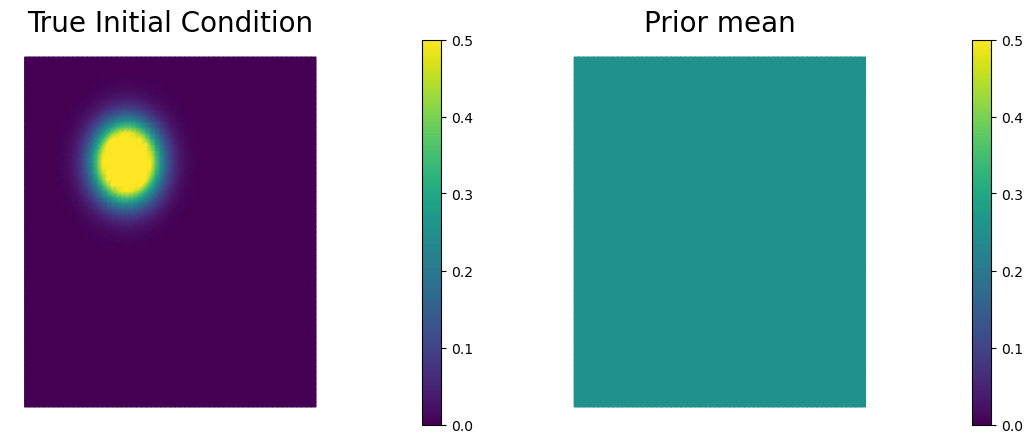

In [4]:
# ═══════════════════════════════════════════════════════════════
# 4.  MESH, FE SPACE, PRIOR, TRUE IC
# ═══════════════════════════════════════════════════════════════
nx, ny = 60, 60
mesh   = dl.UnitSquareMesh(nx, ny)
wind_velocity = computeVelocityField(mesh)
Vh = dl.FunctionSpace(mesh, "Lagrange", 1)
print("Number of dofs:", Vh.dim())

ic_expr = dl.Expression(
    'std::min(0.5, std::exp(-100*(std::pow(x[0]-0.35,2)'
    '+std::pow(x[1]-0.7,2))))',
    element=Vh.ufl_element())
true_initial_condition = dl.interpolate(ic_expr, Vh).vector()

gamma = 1.0
delta = 8.0
prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()

nb.multi1_plot([dl.Function(Vh, true_initial_condition),
                dl.Function(Vh, prior.mean)],
               ["True Initial Condition", "Prior mean"])
plt.show()

In [5]:
# ═══════════════════════════════════════════════════════════════
# 5.  TIME GRIDS
# ═══════════════════════════════════════════════════════════════
t_init         = 0.0
t_final        = 4.0
t_1            = 1.0
dt             = 0.1
observation_dt = 0.2
 
simulation_times  = np.arange(t_init, t_final + 0.5*dt, dt)
observation_times = np.arange(t_1,    t_final + 0.5*dt, observation_dt)
 
print(f"Simulation steps : {len(simulation_times)}")
print(f"Observation times: {len(observation_times)}  "
      f"(t ∈ [{observation_times[0]}, {observation_times[-1]}])")

Simulation steps : 41
Observation times: 16  (t ∈ [1.0, 3.999999999999999])


In [6]:
# ═══════════════════════════════════════════════════════════════
# 6.  GLOBAL OED PARAMETERS
# ═══════════════════════════════════════════════════════════════
K        = 3                          # Fourier modes → m ∈ R^{14}
Ty       = (t_1, t_final)            # time window for frequencies
T_window = t_final - t_1             # = 3.0
omegas   = fourier_frequencies(Ty, K)
r_modes  = 20                        # eigenvalues kept
noise_variance = 1e-4
rel_noise      = 0.01
 
# ── initial Fourier coefficients (matching user's discretisation) ──
xbar_init = np.array([0.35, 0.70])
coeffs_init = np.array([
    [0.10, 0.00, 0.00, 0.08],        # mode 1: θ₁ φ₁ ψ₁ η₁
    [0.05, 0.03, 0.02, 0.00],        # mode 2
    [0.02, 0.01, 0.00, 0.02],        # mode 3
], dtype=float)
m_fourier_init = xbar_coeffs_to_m(xbar_init, coeffs_init, K)
 
# parameter values at which sensors are placed along the curve
t_param = observation_times           # one sensor per observation time
# ── penalty / constraint parameters ──
zeta_bdy   = 1000.0    # boundary penalty weight
zeta_speed = 500.0      # speed penalty weight
v_max      = 0.5        # max sensor speed (domain units / time unit)
# ── obstacles ──
# ── obstacles ──
obstacles = [
    {'type': 'circle',    'center': (0.6, 0.7), 'radius': 0.08, 'margin': 0.05},
    {'type': 'rectangle', 'lower': (0.15, 0.35), 'upper': (0.25, 0.55), 'margin': 0.05},
]

In [7]:
def boundary_penalty_dense(m_fourier, zeta=None, eps_bdy=0.02, n_dense=200):
    if zeta is None:
        zeta = zeta_bdy
    """Evaluate boundary penalty on a dense grid for robustness."""
    t_dense = np.linspace(t_param[0], t_param[-1], n_dense)
    dt_dense = t_dense[1] - t_dense[0]
    targets_dense = generate_targets(m_fourier, t_dense, K, omegas)
    
    val = 0.0
    S_B_dense = np.zeros((n_dense, 2))
    margin = 0.05
    for d in range(2):
        for j in range(n_dense):
            lo = targets_dense[j, d] - eps_bdy
            hi = (1.0 - eps_bdy) - targets_dense[j, d]
            if lo < margin:
                val              += dt_dense * zeta * (margin - lo)**2
                S_B_dense[j, d]  -= zeta * 2.0 * (margin - lo)
            if hi < margin:
                val              += dt_dense * zeta * (margin - hi)**2
                S_B_dense[j, d]  += zeta * 2.0 * (margin - hi)
    
    # Project onto Fourier directly (with dt_dense weight)
    g = np.zeros(4*K + 2)
    g[0] = dt_dense * np.sum(S_B_dense[:, 0])
    g[1] = dt_dense * np.sum(S_B_dense[:, 1])
    for kk in range(K):
        cos_v = np.cos(omegas[kk] * t_dense)
        sin_v = np.sin(omegas[kk] * t_dense)
        g[2 + 4*kk] = dt_dense * np.dot(S_B_dense[:, 0], cos_v)
        g[3 + 4*kk] = dt_dense * np.dot(S_B_dense[:, 0], sin_v)
        g[4 + 4*kk] = dt_dense * np.dot(S_B_dense[:, 1], cos_v)
        g[5 + 4*kk] = dt_dense * np.dot(S_B_dense[:, 1], sin_v)
    return val, g
def fourier_velocity(m_fourier, t_arr, K, omegas):
    """Compute dx/dt, dy/dt at each time in t_arr."""
    xbar, coeffs = m_to_xbar_coeffs(m_fourier, K)
    vx = np.zeros(len(t_arr))
    vy = np.zeros(len(t_arr))
    for k, w in enumerate(omegas):
        vx += w * (-coeffs[k, 0] * np.sin(w * t_arr) + coeffs[k, 1] * np.cos(w * t_arr))
        vy += w * (-coeffs[k, 2] * np.sin(w * t_arr) + coeffs[k, 3] * np.cos(w * t_arr))
    return vx, vy

def speed_penalty_dense(m_fourier, v_max_arg=None, zeta_speed_arg=None, n_dense=200):
    if v_max_arg is None:
        v_max_arg = v_max
    if zeta_speed_arg is None:
        zeta_speed_arg = zeta_speed
    t_dense = np.linspace(t_param[0], t_param[-1], n_dense)
    dt_dense = t_dense[1] - t_dense[0]
    
    vx, vy = fourier_velocity(m_fourier, t_dense, K, omegas)
    speed2 = vx**2 + vy**2
    v_max2 = v_max_arg**2
    
    # Penalty: sum over times where speed exceeds v_max
    excess = np.maximum(0.0, speed2 - v_max2)
    val = dt_dense * zeta_speed_arg * np.sum(excess**2)    
    # Gradient: d/dm of ζ ∫ (|v|² − v_max²)² dt
    # = ζ ∫ 2(|v|² − v_max²) · 2(vx dvx/dm + vy dvy/dm) dt
    # where excess > 0
    
    # Weight at each time: 4 ζ (|v|² − v_max²) where excess > 0
    weight = 4.0 * zeta_speed_arg * excess    
    g = np.zeros(4*K + 2)
    # x̄ and ȳ don't affect velocity → g[0] = g[1] = 0
    
    for kk in range(K):
        w = omegas[kk]
        sin_v = np.sin(w * t_dense)
        cos_v = np.cos(w * t_dense)
        
        # dvx/dθ_k = -ω_k sin(ω_k t),  dvx/dφ_k = ω_k cos(ω_k t)
        # dvy/dψ_k = -ω_k sin(ω_k t),  dvy/dη_k = ω_k cos(ω_k t)
        
        dvx_dtheta = -w * sin_v
        dvx_dphi   =  w * cos_v
        dvy_dpsi   = -w * sin_v
        dvy_deta   =  w * cos_v
        
        # Chain rule: weight * (vx * dvx/dm + vy * dvy/dm)
        g[2 + 4*kk] = dt_dense * np.dot(weight * vx, dvx_dtheta)  # ∂/∂θ_k
        g[3 + 4*kk] = dt_dense * np.dot(weight * vx, dvx_dphi)    # ∂/∂φ_k
        g[4 + 4*kk] = dt_dense * np.dot(weight * vy, dvy_dpsi)    # ∂/∂ψ_k
        g[5 + 4*kk] = dt_dense * np.dot(weight * vy, dvy_deta)    # ∂/∂η_k
    
    return val, g
def define_obstacles(obstacle_list=None):
    """
    Define obstacles as a list of dictionaries.
    
    Each obstacle has:
        'type':   'circle' or 'rectangle'
        'center': (cx, cy)         — for circle
        'radius': r                — for circle
        'lower':  (xmin, ymin)     — for rectangle
        'upper':  (xmax, ymax)     — for rectangle
        'margin': safety distance around the obstacle
    """
    if obstacle_list is None:
        # Default: one circular obstacle (building) and one rectangular (no-fly zone)
        obstacle_list = [
            {'type': 'circle', 'center': (0.6, 0.7), 'radius': 0.08, 'margin': 0.03},
            {'type': 'rectangle', 'lower': (0.15, 0.35), 'upper': (0.25, 0.55), 'margin': 0.03},
        ]
    return obstacle_list

def signed_distance_to_obstacle(xy, obs):
    """
    Signed distance from point xy to obstacle boundary.
    Negative = inside obstacle, positive = outside.
    """
    x, y = xy[0], xy[1]
    
    if obs['type'] == 'circle':
        cx, cy = obs['center']
        r = obs['radius']
        dist = np.sqrt((x - cx)**2 + (y - cy)**2) - r
        # Gradient of distance w.r.t. (x, y)
        d = np.sqrt((x - cx)**2 + (y - cy)**2)
        if d < 1e-12:
            grad_dist = np.array([1.0, 0.0])  # arbitrary direction at center
        else:
            grad_dist = np.array([(x - cx) / d, (y - cy) / d])
        return dist, grad_dist
    
    elif obs['type'] == 'rectangle':
        xmin, ymin = obs['lower']
        xmax, ymax = obs['upper']
        
        # Distance to nearest edge (negative inside)
        dx = max(xmin - x, 0, x - xmax)
        dy = max(ymin - y, 0, y - ymax)
        
        if dx == 0 and dy == 0:
            # Inside rectangle — distance is negative
            dist = -min(x - xmin, xmax - x, y - ymin, ymax - y)
            # Gradient points toward nearest edge
            dists_to_edges = [x - xmin, xmax - x, y - ymin, ymax - y]
            min_idx = np.argmin(dists_to_edges)
            grad_dist = [np.array([-1, 0]), np.array([1, 0]),
                         np.array([0, -1]), np.array([0, 1])][min_idx]
        else:
            dist = np.sqrt(dx**2 + dy**2)
            gx = 0.0
            gy = 0.0
            if x < xmin:
                gx = (x - xmin)
            elif x > xmax:
                gx = (x - xmax)
            if y < ymin:
                gy = (y - ymin)
            elif y > ymax:
                gy = (y - ymax)
            norm = np.sqrt(gx**2 + gy**2)
            if norm < 1e-12:
                grad_dist = np.array([1.0, 0.0])
            else:
                grad_dist = np.array([gx / norm, gy / norm])
        
        return dist, grad_dist

def obstacle_penalty_dense(m_fourier, obstacles, zeta_obs=2000.0, n_dense=200):
    """
    Penalize path entering obstacle + margin zone.
    
    For each obstacle with margin m:
        penalty += ζ * max(0, margin - dist)^2
    
    where dist is signed distance from path to obstacle boundary.
    """
    t_dense = np.linspace(t_param[0], t_param[-1], n_dense)
    dt_dense = t_dense[1] - t_dense[0]
    targets_dense = generate_targets(m_fourier, t_dense, K, omegas)
    
    val = 0.0
    # Sensitivity w.r.t. sensor position: S_obs(t) ∈ R^2
    S_obs = np.zeros((n_dense, 2))
    
    for obs in obstacles:
        margin = obs['margin']
        for j in range(n_dense):
            pt = targets_dense[j]
            dist, grad_dist = signed_distance_to_obstacle(pt, obs)
            
            total_margin = obs.get('radius', 0) * 0 + margin  # just the margin
            penetration = margin - dist  # positive when too close
            
            if penetration > 0:
                val += dt_dense * zeta_obs * penetration**2
                # d/d(position) of ζ*(margin - dist)^2 = -2ζ*(margin - dist) * grad_dist
                S_obs[j, 0] += -zeta_obs * 2.0 * penetration * grad_dist[0]
                S_obs[j, 1] += -zeta_obs * 2.0 * penetration * grad_dist[1]
    
    # Project onto Fourier basis (with dt_dense weight)
    g = np.zeros(4*K + 2)
    g[0] = dt_dense * np.sum(S_obs[:, 0])
    g[1] = dt_dense * np.sum(S_obs[:, 1])
    for kk in range(K):
        cos_v = np.cos(omegas[kk] * t_dense)
        sin_v = np.sin(omegas[kk] * t_dense)
        g[2 + 4*kk] = dt_dense * np.dot(S_obs[:, 0], cos_v)
        g[3 + 4*kk] = dt_dense * np.dot(S_obs[:, 0], sin_v)
        g[4 + 4*kk] = dt_dense * np.dot(S_obs[:, 1], cos_v)
        g[5 + 4*kk] = dt_dense * np.dot(S_obs[:, 1], sin_v)
    
    return val, g
def get_snapshot(traj, t, sim_times, Vh):
    idx       = int(np.argmin(np.abs(sim_times - t)))
    t_closest = float(sim_times[idx])
    assert abs(t_closest - t) < 1e-10, f"Time {t} not in simulation grid (nearest: {t_closest})"
    snap = dl.Function(Vh).vector()
    traj.retrieve(snap, t_closest)
    return snap
_cached_bbt = None

def eval_fn_and_grad_P1(func, mesh, pt_xy):
    global _cached_bbt
    pt  = dl.Point(float(pt_xy[0]), float(pt_xy[1]))
    val = func(pt)

    if _cached_bbt is None:
        _cached_bbt = mesh.bounding_box_tree()
    cid = _cached_bbt.compute_first_entity_collision(pt)
    if cid >= mesh.num_cells():
        return float(val), np.zeros(2)

    cell = dl.Cell(mesh, cid)

    try:
        coords = cell.get_vertex_coordinates().reshape(-1, 2)
    except AttributeError:
        verts  = cell.entities(0)
        all_coords = mesh.coordinates()
        coords = all_coords[verts]

    dofs  = func.function_space().dofmap().cell_dofs(cid)
    u_nod = np.array(func.vector()[dofs])

    A = np.column_stack([np.ones(3), coords])
    try:
        abc = np.linalg.solve(A, u_nod)
    except np.linalg.LinAlgError:
        return float(val), np.zeros(2)
    return float(val), abc[1:]


In [8]:
# ═══════════════════════════════════════════════════════════════
# 8.  BUILD PROBLEM  (uses hIPPYlib's SpaceTimePointwiseStateObservation)
# ═══════════════════════════════════════════════════════════════
class MovingSensorMisfit:
    """
    Moving sensor: at observation time t_k, only target k is active.
    Matches SpaceTimePointwiseStateObservation interface exactly.
    """
    
    def __init__(self, Vh, observation_times, targets):
        self.Vh = Vh
        self.observation_times = observation_times
        self.n_obs = len(observation_times)
        self.targets = targets
        self.noise_variance = 1.0
        
        assert targets.shape[0] == self.n_obs
        
        # One B_k (1 × N_dof) per observation time
        self.B_list = []
        for k in range(self.n_obs):
            B_k = assemblePointwiseObservation(Vh, targets[k:k+1, :])
            self.B_list.append(B_k)
        
        # Also store B_list[0] as self.B so hIPPYlib internals don't break
        self.B = self.B_list[0]
        
        # Data: obs-space vectors (dim 1) at each time
        self.d = TimeDependentVector(observation_times)
        self.d.data = []
        for k in range(self.n_obs):
            v = dl.Vector()
            self.B.init_vector(v, 0)
            self.d.data.append(v)
        
        # Pre-allocate work vectors
        self.u_snapshot  = dl.Vector()
        self.Bu_snapshot = dl.Vector()
        self.d_snapshot  = dl.Vector()
        self.B.init_vector(self.u_snapshot, 1)   # N_dof
        self.B.init_vector(self.Bu_snapshot, 0)  # dim 1
        self.B.init_vector(self.d_snapshot, 0)   # dim 1
    
    def observe(self, x, d):
        for k in range(self.n_obs):
            tk = self.observation_times[k]
            x[STATE].retrieve(self.u_snapshot, tk)
            self.B_list[k].mult(self.u_snapshot, self.Bu_snapshot)
            d.store(self.Bu_snapshot, tk)
    
    def cost(self, x):
        c = 0.0
        for k in range(self.n_obs):
            tk = self.observation_times[k]
            x[STATE].retrieve(self.u_snapshot, tk)
            self.B_list[k].mult(self.u_snapshot, self.Bu_snapshot)
            self.d.retrieve(self.d_snapshot, tk)
            self.Bu_snapshot.axpy(-1.0, self.d_snapshot)
            c += self.Bu_snapshot.inner(self.Bu_snapshot)
        return 0.5 * c / self.noise_variance
    
    def grad(self, i, x, out):
        out.zero()
        if i == STATE:
            for k in range(self.n_obs):
                tk = self.observation_times[k]
                x[STATE].retrieve(self.u_snapshot, tk)
                self.B_list[k].mult(self.u_snapshot, self.Bu_snapshot)
                self.d.retrieve(self.d_snapshot, tk)
                self.Bu_snapshot.axpy(-1.0, self.d_snapshot)
                self.Bu_snapshot *= 1.0 / self.noise_variance
                self.B_list[k].transpmult(self.Bu_snapshot, self.u_snapshot)
                out.store(self.u_snapshot, tk)
        else:
            pass
    
    def setLinearizationPoint(self, x, gauss_newton_approx=False):
        pass
    
    def apply_ij(self, i, j, direction, out):
        out.zero()
        if i == STATE and j == STATE:
            for k in range(self.n_obs):
                tk = self.observation_times[k]
                direction.retrieve(self.u_snapshot, tk)
                self.B_list[k].mult(self.u_snapshot, self.Bu_snapshot)
                self.Bu_snapshot *= 1.0 / self.noise_variance
                self.B_list[k].transpmult(self.Bu_snapshot, self.u_snapshot)
                out.store(self.u_snapshot, tk)
        else:
            pass

_template_problem = None

def build_problem(m_fourier):
    global _template_problem
    targets = generate_targets(m_fourier, t_param, K, omegas)
    misfit = MovingSensorMisfit(Vh, observation_times, targets)
    misfit.noise_variance = noise_variance

    problem = TimeDependentAD(
        mesh, [Vh, Vh, Vh], prior, misfit,
        simulation_times, wind_velocity, True
    )
    return problem, misfit, targets

In [9]:
# ═══════════════════════════════════════════════════════════════
# 9.  EIGENDECOMPOSITION
# ═══════════════════════════════════════════════════════════════
class CachedEigensolver:
    def __init__(self):
        self.Omega = None
    
    def solve(self, prob, prior, r):
        u_lin = prob.generate_vector(STATE)
        m_lin = prob.generate_vector(PARAMETER)
        p_lin = prob.generate_vector(ADJOINT)

        prob.solveFwd(u_lin, [u_lin, m_lin, p_lin])
        prob.solveAdj(p_lin, [u_lin, m_lin, p_lin])

        H     = ReducedHessian(prob, misfit_only=True)
        Omega = MultiVector(m_lin, r + 10)

        if self.Omega is None:
            parRandom.normal(1.0, Omega)
            self.Omega = MultiVector(m_lin, r + 10)
            for i in range(r + 10):
                self.Omega[i].zero()
                self.Omega[i].axpy(1.0, Omega[i])
        else:
            for i in range(r + 10):
                Omega[i].zero()
                Omega[i].axpy(1.0, self.Omega[i])

        lmbda, V = doublePassG(H, prior.R, prior.Rsolver, Omega, r)
        # Clip tiny/negative eigenvalues from numerical noise
        lmbda = np.maximum(lmbda, 0.0)
        EIG = float(np.sum(np.log(1.0 + lmbda)))
        return lmbda, V, EIG
        
    def reset(self):
        self.Omega = None

eigsolver = CachedEigensolver()

def compute_eigendecomposition(prob, prior, r):
    return eigsolver.solve(prob, prior, r)

In [10]:
# ═══════════════════════════════════════════════════════════════
# 10.  OED OBJECTIVE AND GRADIENT
# ═══════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════
# 10.  OED OBJECTIVE AND GRADIENT
# ═══════════════════════════════════════════════════════════════
import time
opt_history = {'eig': [], 'bdy': [], 'spd': [], 'J': [], 'time': []}
def EIG_objective_and_grad(m_fourier):
    _t0 = time.time()
 
    # 10.1  build problem and get eigenpairs
    prob, msft, tgts = build_problem(m_fourier)
    lmbda, V, EIG_val = compute_eigendecomposition(prob, prior, r=r_modes)
 
    # 10.2  forward trajectories  ũ_i  (one per eigenmode)
    lmbda_thresh = 1e-2
    n_active = max(1, int(np.sum(lmbda > lmbda_thresh)))
    
    u_tilde_trajs = []
    for i in range(n_active):
        v_i = dl.Function(Vh).vector()
        v_i.axpy(1.0, V[i])
        u_t = prob.generate_vector(STATE)
        prob.solveFwd(u_t, [u_t, v_i, None])
        u_tilde_trajs.append(u_t)
 
    # 10.3  sensitivity  S(t_j) ∈ R^{M×2}
    #       Moving sensor: one observation per time step
    n_obs = len(observation_times)
    S = np.zeros((n_obs, 2))
    for j in range(n_obs):
            cj = tgts[j]
            tj = observation_times[j]
            for i in range(n_active):
                scale_i = 2.0 / ((1.0 + max(lmbda[i], 0.0)) * noise_variance)
                snap = get_snapshot(u_tilde_trajs[i], tj,
                                    simulation_times, Vh)
                f_t = dl.Function(Vh)
                f_t.vector().zero()
                f_t.vector().axpy(1.0, snap)
                ut_val, gut = eval_fn_and_grad_P1(f_t, mesh, cj)
                S[j, 0] += scale_i * ut_val * gut[0]
                S[j, 1] += scale_i * ut_val * gut[1]
 
    # 10.4  project onto Fourier basis → ∂EIG/∂m
    def project_to_fourier(S_mat):
            g = np.zeros(4*K + 2)
            g[0] = np.sum(S_mat[:, 0])
            g[1] = np.sum(S_mat[:, 1])
            for kk in range(K):
                cos_v = np.cos(omegas[kk] * t_param)
                sin_v = np.sin(omegas[kk] * t_param)
                g[2 + 4*kk] = np.dot(S_mat[:, 0], cos_v)
                g[3 + 4*kk] = np.dot(S_mat[:, 0], sin_v)
                g[4 + 4*kk] = np.dot(S_mat[:, 1], cos_v)
                g[5 + 4*kk] = np.dot(S_mat[:, 1], sin_v)
            return g
     
    grad_eig = project_to_fourier(S)
 
    # 10.5  boundary penalty (dense grid)
    pen_val, grad_pen = boundary_penalty_dense(m_fourier)

    # 10.6  speed penalty (dense grid)
    spd_val, grad_spd = speed_penalty_dense(m_fourier)

    # 10.7  obstacle avoidance penalty (dense grid)
    obs_val, grad_obs = obstacle_penalty_dense(m_fourier, obstacles)

    _elapsed = time.time() - _t0
    J = -EIG_val + pen_val + spd_val + obs_val
    
    opt_history['eig'].append(EIG_val)
    opt_history['bdy'].append(pen_val)
    opt_history['spd'].append(spd_val)
    opt_history['J'].append(J)
    opt_history['time'].append(_elapsed)
    
    print(f"  EIG={EIG_val:.4f}  bdy={pen_val:.4f}  spd={spd_val:.4f}  obs={obs_val:.4f}  [{_elapsed:.1f}s]")
 
    return (J, -grad_eig + grad_pen + grad_spd + grad_obs)

In [11]:
# ═══════════════════════════════════════════════════════════════
# 11.  FINITE-DIFFERENCE GRADIENT CHECK
# ═══════════════════════════════════════════════════════════════
def check_oed_gradient(m_test, eps=1e-5, ncheck=6):
    J0, g0 = EIG_objective_and_grad(m_test)
    print(f"\nBase objective: {J0:.6f}")
    print(f"{'idx':>4s}  {'analytic':>12s}  {'FD':>12s}  {'rel_err':>10s}")
    print("-" * 48)
    for idx in np.random.choice(len(m_test),
                                size=min(ncheck, len(m_test)),
                                replace=False):
        dm      = np.zeros_like(m_test)
        dm[idx] = eps
        Jp, _   = EIG_objective_and_grad(m_test + dm)
        Jm, _   = EIG_objective_and_grad(m_test - dm)
        fd      = (Jp - Jm) / (2.0 * eps)
        rerr    = abs(g0[idx] - fd) / (abs(fd) + 1e-15)
        print(f"  {idx:2d}   {g0[idx]: .5e}   {fd: .5e}   {rerr:.2e}")

In [12]:
 #═══════════════════════════════════════════════════════════════
# 12.  SENSOR DISTRIBUTION PLOT
# ═══════════════════════════════════════════════════════════════
def plot_sensor_distribution(m_fourier, title="Sensor distribution",
                             show_ic=True, show_velocity=True):
    targets = generate_targets(m_fourier, t_param, K, omegas)
    n_sensors = targets.shape[0]  # <-- use local variable instead of global M

    t_dense = np.linspace(t_param[0], t_param[-1], 200)
    loop_dense = generate_targets(m_fourier, t_dense, K, omegas)

    fig, axes = plt.subplots(1, 2 if show_velocity else 1,
                             figsize=(14 if show_velocity else 7, 6))
    if not show_velocity:
        axes = [axes]

    ax = axes[0]
    if show_ic:
        ic_func = dl.Function(Vh, true_initial_condition)
        p = dl.plot(ic_func)
        plt.colorbar(p, ax=ax, fraction=0.046, pad=0.04)

    ax.plot(loop_dense[:, 0], loop_dense[:, 1],
            'w-', lw=1.5, alpha=0.6, label='Fourier loop')
    sc = ax.scatter(targets[:, 0], targets[:, 1],
                    c=np.arange(n_sensors), cmap='hot', s=80,
                    edgecolors='white', linewidths=1.2, zorder=5)
    ax.annotate(f't={t_param[0]:.1f}',
                xy=targets[0], fontsize=8,
                xytext=(5, 5), textcoords='offset points',
                color='white', fontweight='bold')
    ax.annotate(f't={t_param[-1]:.1f}',
                xy=targets[-1], fontsize=8,
                xytext=(5, -10), textcoords='offset points',
                color='white', fontweight='bold')

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal', 'box')
    ax.set_title(f'{title}\n({n_sensors} sensors, K={K} Fourier modes)')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(loc='lower right', fontsize=8)

    if show_velocity:
        ax2 = axes[1]
        mc = dl.UnitSquareMesh(20, 20)
        vc = dl.interpolate(wind_velocity,
                            dl.VectorFunctionSpace(mc, "CG", 1))
        coords_v = mc.coordinates()
        vals_v   = vc.compute_vertex_values(mc)
        n_v      = len(coords_v)
        vx = vals_v[:n_v]
        vy = vals_v[n_v:]
        speed = np.sqrt(vx**2 + vy**2)

        ax2.quiver(coords_v[:, 0], coords_v[:, 1], vx, vy, speed,
                   cmap='coolwarm', alpha=0.6, scale=8)
        ax2.plot(loop_dense[:, 0], loop_dense[:, 1],
                 'k-', lw=1.5, alpha=0.6, label='Fourier loop')
        ax2.scatter(targets[:, 0], targets[:, 1],
                    c=np.arange(n_sensors), cmap='hot', s=80,
                    edgecolors='black', linewidths=1.2, zorder=5)
        ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
        ax2.set_aspect('equal', 'box')
        ax2.set_title('Sensors on velocity field')
        ax2.set_xlabel('x'); ax2.set_ylabel('y')
        ax2.legend(loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()
    return targets
def draw_obstacles(ax, obstacles):
    """Draw obstacles on an axis."""
    for obs in obstacles:
        if obs['type'] == 'circle':
            cx, cy = obs['center']
            r = obs['radius']
            m = obs['margin']
            # Obstacle body
            circle = plt.Circle((cx, cy), r, color='red', alpha=0.6, zorder=4)
            ax.add_patch(circle)
            # Safety margin
            margin_circle = plt.Circle((cx, cy), r + m, color='red',
                                        alpha=0.15, linestyle='--',
                                        fill=True, zorder=3)
            ax.add_patch(margin_circle)
        
        elif obs['type'] == 'rectangle':
            xmin, ymin = obs['lower']
            xmax, ymax = obs['upper']
            m = obs['margin']
            w = xmax - xmin
            h = ymax - ymin
            # Obstacle body
            rect = plt.Rectangle((xmin, ymin), w, h,
                                  color='red', alpha=0.6, zorder=4)
            ax.add_patch(rect)
            # Safety margin
            rect_m = plt.Rectangle((xmin - m, ymin - m), w + 2*m, h + 2*m,
                                    color='red', alpha=0.15, linestyle='--',
                                    fill=True, zorder=3)
            ax.add_patch(rect_m)


  INITIAL SENSOR DISTRIBUTION


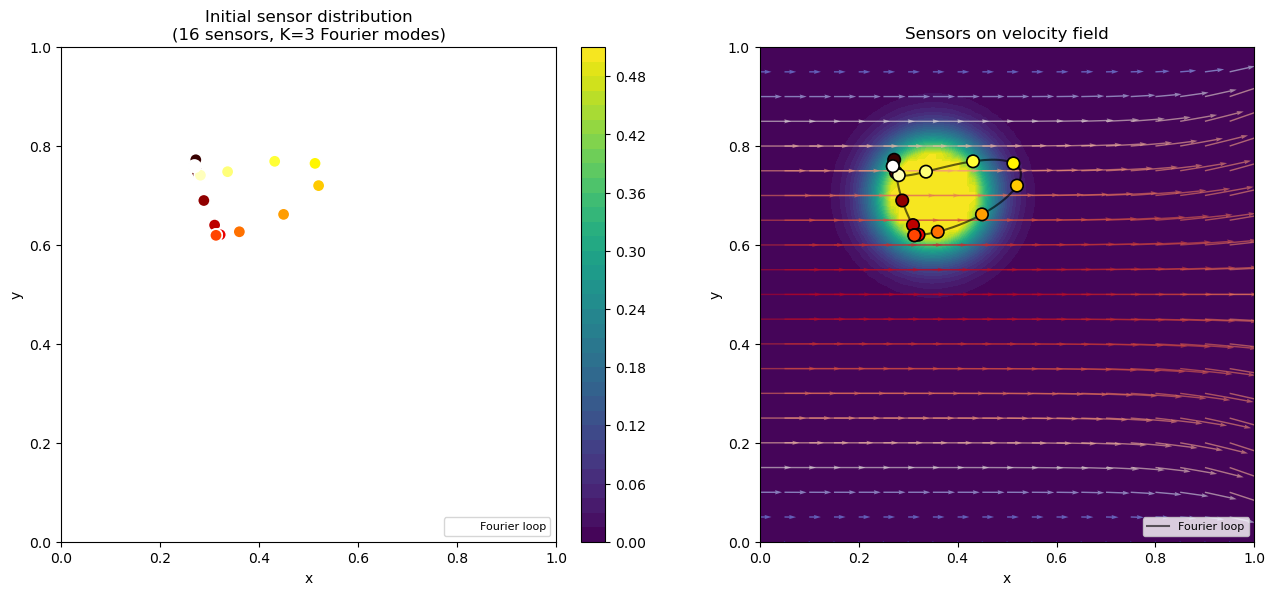

Number of sensors: 16
Observation times: 16
  noise_variance = 1.000000e-04

--- Model verification ---
(yy, H xx) - (xx, H yy) =  -1.2287472785977459e-14
(g,g) = 8134662749365.357

Initial-path EIG = 12.223146


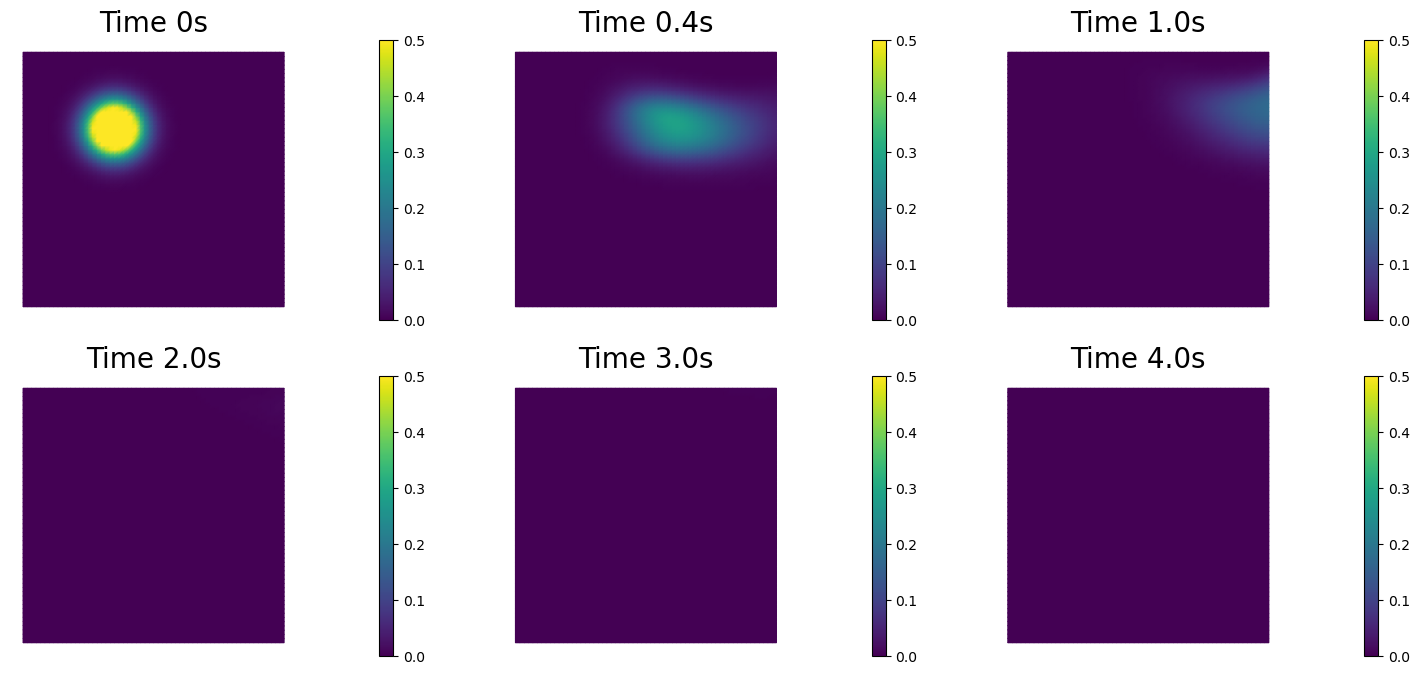

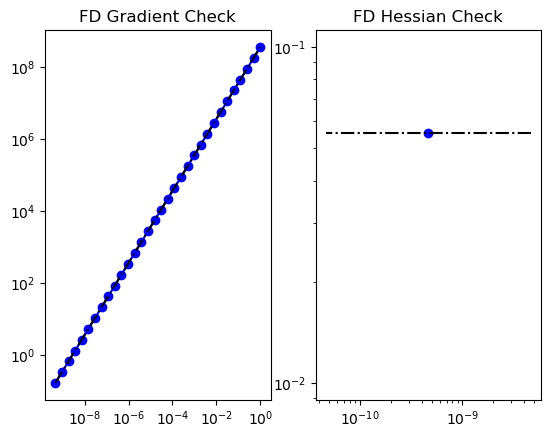

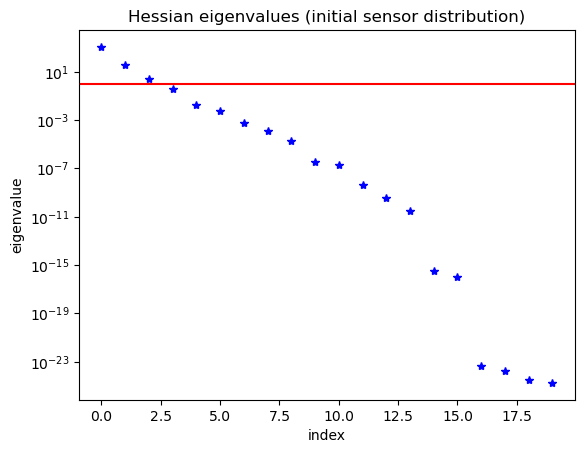

 Iterartion :  0  (B r, r) =  9903.27137975664
 Iteration :  1  (B r, r) =  3.7394141089504106e-14
Relative/Absolute residual less than tol
Converged in  1  iterations with final norm  1.9337564761237156e-07
Total cost 12.4328;  Reg 5.35257;  Misfit 7.08025


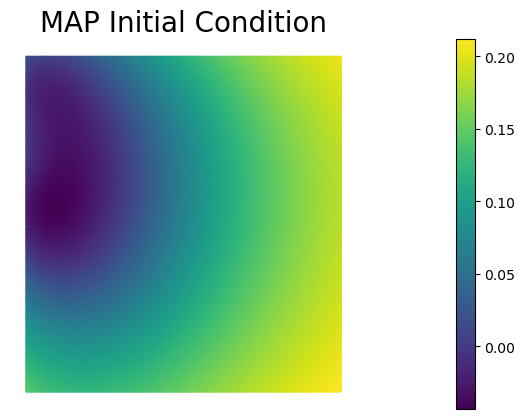

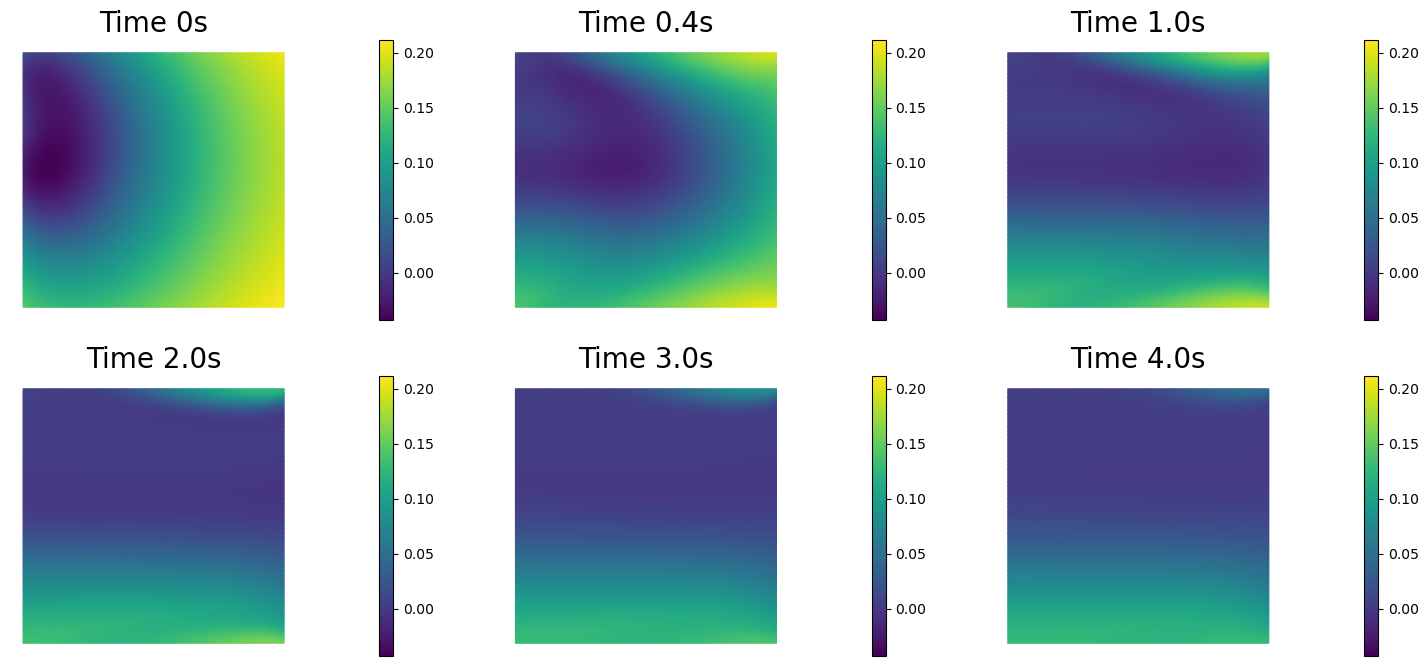

Posterior trace 0.00718421;  Prior trace 0.0104072


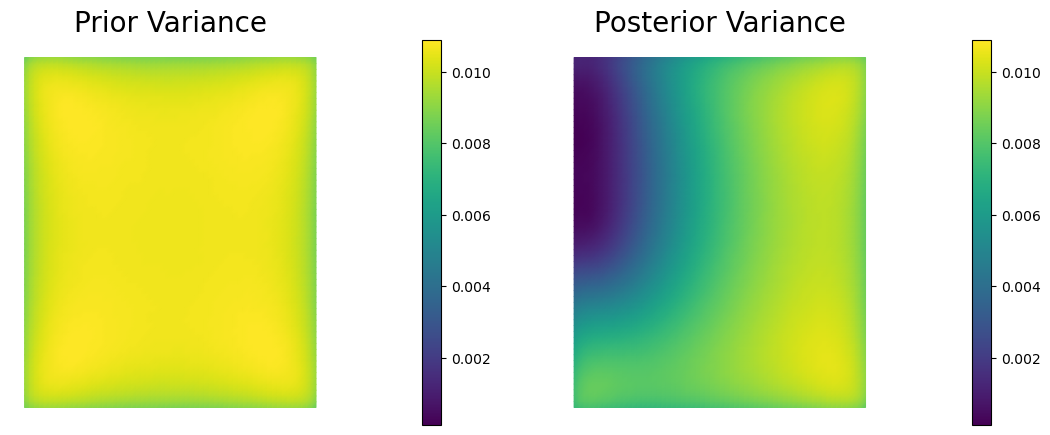

In [13]:
# ═══════════════════════════════════════════════════════════════
# 13a.  INITIAL SENSOR DISTRIBUTION
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  INITIAL SENSOR DISTRIBUTION")
print("="*60)

targets_init = plot_sensor_distribution(m_fourier_init,
                                        title="Initial sensor distribution")
n_sensors = targets_init.shape[0]
print(f"Number of sensors: {n_sensors}")
print(f"Observation times: {len(observation_times)}")
# ═══════════════════════════════════════════════════════════════
# 13b.  MODEL VERIFICATION
# ═══════════════════════════════════════════════════════════════
prob_v, msft_v, tgts_v = build_problem(m_fourier_init)

# Synthetic data
utrue_v = prob_v.generate_vector(STATE)
x_v     = [utrue_v, true_initial_condition, None]
prob_v.solveFwd(utrue_v, x_v)
msft_v.observe(x_v, msft_v.d)

noise_std_dev = np.sqrt(noise_variance)
for k in range(msft_v.n_obs):
    arr = msft_v.d.data[k].get_local()
    arr[0] += noise_std_dev * np.random.randn()
    msft_v.d.data[k].set_local(arr)
msft_v.noise_variance = noise_variance
print(f"  noise_variance = {msft_v.noise_variance:.6e}")

nb.show_solution(Vh, true_initial_condition, utrue_v, "True solution")

print("\n--- Model verification ---")
m0 = true_initial_condition.copy()
_ = modelVerify(prob_v, m0, is_quadratic=True)
# ═══════════════════════════════════════════════════════════════
# 13c.  SOLVE INVERSE PROBLEM
# ═══════════════════════════════════════════════════════════════
[u_v, m_v, p_v] = prob_v.generate_vector()
m_v.axpy(1.0, prior.mean)
prob_v.solveFwd(u_v, [u_v, m_v, p_v])
prob_v.solveAdj(p_v, [u_v, m_v, p_v])
mg_v      = prob_v.generate_vector(PARAMETER)
grad_norm = prob_v.evalGradientParameter([u_v, m_v, p_v], mg_v)
print("(g,g) =", grad_norm)

lmbda_v, V_v, EIG_v = compute_eigendecomposition(prob_v, prior, r_modes)
print(f"\nInitial-path EIG = {EIG_v:.6f}")

posterior_v = GaussianLRPosterior(prior, lmbda_v, V_v)

plt.figure()
plt.plot(range(r_modes), lmbda_v, 'b*')
plt.axhline(1.0, color='r')
plt.yscale('log')
plt.xlabel('index'); plt.ylabel('eigenvalue')
plt.title('Hessian eigenvalues (initial sensor distribution)')
plt.show()

H_v = ReducedHessian(prob_v, misfit_only=False)
solver = CGSolverSteihaug()
solver.set_operator(H_v)
solver.set_preconditioner(posterior_v.Hlr)
solver.parameters["print_level"]   = 1
solver.parameters["rel_tolerance"] = 1e-6

rhs = mg_v.copy(); rhs *= -1.0
dm  = prob_v.generate_vector(PARAMETER)
solver.solve(dm, rhs)

m_v.axpy(1.0, dm)
prob_v.solveFwd(u_v, [u_v, m_v, p_v])

tc, rc, mc = prob_v.cost([u_v, m_v, p_v])
print(f"Total cost {tc:5g};  Reg {rc:5g};  Misfit {mc:5g}")

posterior_v.mean = m_v

nb.plot(dl.Function(Vh, m_v), mytitle="MAP Initial Condition")
plt.show()
nb.show_solution(Vh, m_v, u_v, "Solution at MAP")
plt.show()
# ═══════════════════════════════════════════════════════════════
# 13d.  POSTERIOR DIAGNOSTICS
# ═══════════════════════════════════════════════════════════════
post_tr, prior_tr, _ = posterior_v.trace(method="Randomized", r=200)
print(f"Posterior trace {post_tr:5g};  Prior trace {prior_tr:5g}")

post_pw, pr_pw, _ = posterior_v.pointwise_variance(method="Randomized", r=200)
nb.multi1_plot([dl.Function(Vh, pr_pw), dl.Function(Vh, post_pw)],
               ["Prior Variance", "Posterior Variance"])
plt.show()

In [14]:
# ═══════════════════════════════════════════════════════════════
# 14.  OED GRADIENT CHECK
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  OED GRADIENT CHECK")
print("="*60)
check_oed_gradient(m_fourier_init, eps=1e-5, ncheck=6)


  OED GRADIENT CHECK
  EIG=12.2231  bdy=0.0000  spd=0.0473  obs=1.0153  [3.3s]

Base objective: -11.160609
 idx      analytic            FD     rel_err
------------------------------------------------
  EIG=12.2231  bdy=0.0000  spd=0.0474  obs=1.0153  [3.3s]
  EIG=12.2232  bdy=0.0000  spd=0.0472  obs=1.0152  [3.2s]
   7    1.76559e+01    1.76617e+01   3.30e-04
  EIG=12.2231  bdy=0.0000  spd=0.0473  obs=1.0153  [3.2s]
  EIG=12.2231  bdy=0.0000  spd=0.0472  obs=1.0152  [3.2s]
   3    8.06180e+00    8.04686e+00   1.86e-03
  EIG=12.2232  bdy=0.0000  spd=0.0474  obs=1.0151  [3.2s]
  EIG=12.2231  bdy=0.0000  spd=0.0472  obs=1.0154  [3.2s]
  12   -9.66153e+00   -9.65833e+00   3.31e-04
  EIG=12.2232  bdy=0.0000  spd=0.0473  obs=1.0151  [3.2s]
  EIG=12.2231  bdy=0.0000  spd=0.0473  obs=1.0154  [3.4s]
   4   -1.78144e+01   -1.77354e+01   4.46e-03
  EIG=12.2232  bdy=0.0000  spd=0.0473  obs=1.0151  [3.2s]
  EIG=12.2231  bdy=0.0000  spd=0.0472  obs=1.0154  [3.2s]
   8   -1.33635e+01   -1.34404e+01


  PATH OPTIMISATION


/tmp/ipykernel_4066315/1038216006.py:22: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(EIG_objective_and_grad, m_fourier_init,


  EIG=12.2231  bdy=0.0000  spd=0.0473  obs=1.0153  [3.2s]
  EIG=21.0256  bdy=8.8576  spd=471649.9021  obs=0.0000  [3.3s]
  EIG=15.9563  bdy=0.8883  spd=233.2031  obs=0.0000  [3.2s]
  EIG=12.9737  bdy=0.0000  spd=0.0288  obs=0.0000  [3.2s]
  EIG=13.4355  bdy=0.0000  spd=0.4509  obs=0.0000  [3.2s]
  EIG=13.1994  bdy=0.0000  spd=0.1507  obs=0.0000  [3.2s]
  EIG=13.4410  bdy=0.0000  spd=0.1808  obs=0.0000  [3.3s]
  EIG=14.5062  bdy=0.0000  spd=0.7829  obs=0.0000  [3.2s]
  EIG=15.8279  bdy=0.0000  spd=0.6424  obs=0.0383  [3.3s]
  EIG=18.3673  bdy=1.3362  spd=45.2269  obs=0.0805  [3.3s]
  EIG=16.1247  bdy=0.0000  spd=0.5115  obs=0.0441  [3.2s]
  EIG=15.2975  bdy=0.0000  spd=0.0000  obs=0.0000  [3.3s]
  EIG=15.8549  bdy=0.0000  spd=0.0096  obs=0.0055  [3.2s]
  EIG=16.2515  bdy=0.0000  spd=0.1255  obs=0.0019  [3.3s]
  EIG=17.3182  bdy=0.1441  spd=0.7758  obs=0.0000  [3.3s]
  EIG=17.2329  bdy=0.0651  spd=0.2632  obs=0.0000  [3.3s]
  EIG=17.6716  bdy=0.2844  spd=0.1426  obs=0.0000  [3.4s]
  EIG=

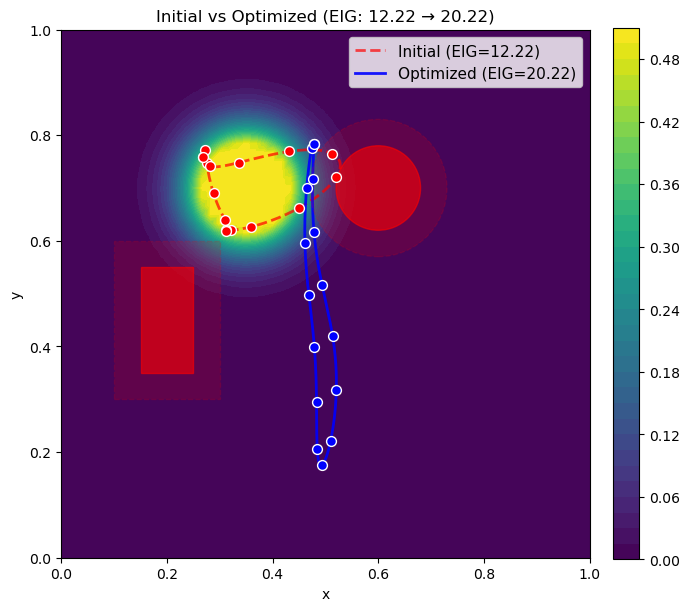

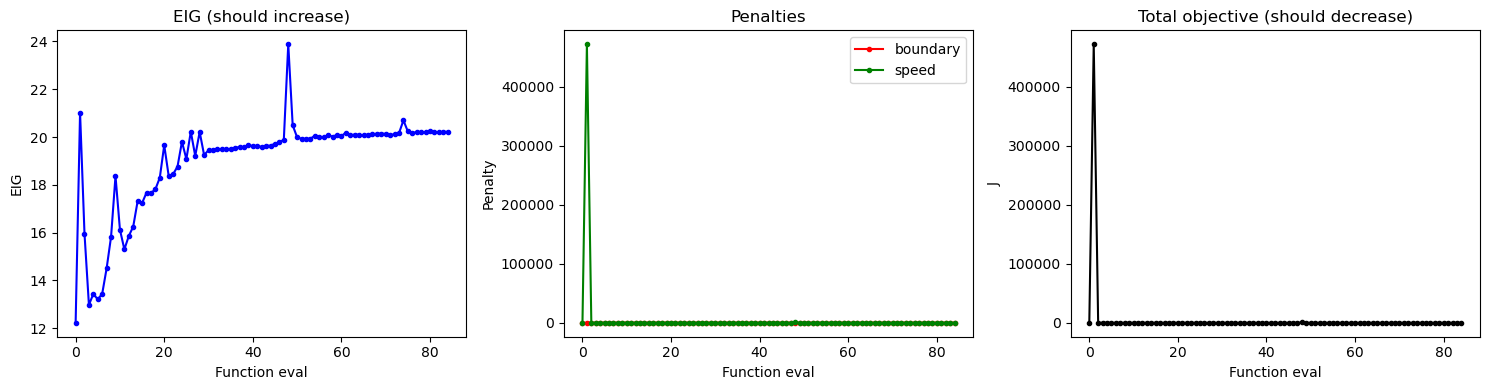

Average time per function eval: 3.3s
Total optimization time: 281s


In [15]:
# ═══════════════════════════════════════════════════════════════
# 15.  OPTIMISE THE SENSOR PATH  (L-BFGS-B)
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  PATH OPTIMISATION")
print("="*60)

eigsolver.reset()
opt_history = {'eig': [], 'bdy': [], 'spd': [], 'J': [], 'time': []}

# Hard bounds: x̄, ȳ ∈ [0.1, 0.9], Fourier amplitudes ∈ [-0.3, 0.3]
lb = np.zeros(4*K + 2)
ub = np.zeros(4*K + 2)
lb[0] = 0.1;  ub[0] = 0.9   # x̄
lb[1] = 0.1;  ub[1] = 0.9   # ȳ
for kk in range(K):
    for j in range(4):
        lb[2 + 4*kk + j] = -0.3
        ub[2 + 4*kk + j] =  0.3
bounds = list(zip(lb, ub))

result = minimize(EIG_objective_and_grad, m_fourier_init,
                  jac=True, method='L-BFGS-B', bounds=bounds,
                  options={'maxiter': 60, 'disp': True, 'ftol': 1e-10,
                           'maxls': 40})

m_opt = result.x
print(f"\nResult: {result.message}")

# ── final EIG ──────────────────────────────────────────────────
_, _, EIG_init = compute_eigendecomposition(build_problem(m_fourier_init)[0], prior, r_modes)
_, _, EIG_opt  = compute_eigendecomposition(build_problem(m_opt)[0], prior, r_modes)
print(f"EIG: {EIG_init:.4f} → {EIG_opt:.4f}")

# ── compare initial and optimised ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

ic_func = dl.Function(Vh, true_initial_condition)
p = dl.plot(ic_func)
plt.colorbar(p, ax=ax, fraction=0.046, pad=0.04)
draw_obstacles(ax, obstacles)

t_dense = np.linspace(t_param[0], t_param[-1], 200)
loop_init = generate_targets(m_fourier_init, t_dense, K, omegas)
loop_opt  = generate_targets(m_opt, t_dense, K, omegas)

ax.plot(loop_init[:, 0], loop_init[:, 1], 'r--', lw=2, alpha=0.7,
        label=f'Initial (EIG={EIG_init:.2f})')
ax.plot(loop_opt[:, 0], loop_opt[:, 1], 'b-', lw=2, alpha=0.9,
        label=f'Optimized (EIG={EIG_opt:.2f})')

tgts_init = generate_targets(m_fourier_init, t_param, K, omegas)
tgts_opt  = generate_targets(m_opt, t_param, K, omegas)
ax.scatter(tgts_init[:, 0], tgts_init[:, 1], c='red', s=50, edgecolors='white', zorder=5)
ax.scatter(tgts_opt[:, 0], tgts_opt[:, 1], c='blue', s=50, edgecolors='white', zorder=5)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal', 'box')
ax.legend(fontsize=11)
ax.set_title(f'Initial vs Optimized (EIG: {EIG_init:.2f} → {EIG_opt:.2f})')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()
# ── convergence plots ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(opt_history['eig'], 'b.-')
axes[0].set_xlabel('Function eval'); axes[0].set_ylabel('EIG')
axes[0].set_title('EIG (should increase)')

axes[1].plot(opt_history['bdy'], 'r.-', label='boundary')
axes[1].plot(opt_history['spd'], 'g.-', label='speed')
axes[1].set_xlabel('Function eval'); axes[1].set_ylabel('Penalty')
axes[1].set_title('Penalties'); axes[1].legend()

axes[2].plot(opt_history['J'], 'k.-')
axes[2].set_xlabel('Function eval'); axes[2].set_ylabel('J')
axes[2].set_title('Total objective (should decrease)')

plt.tight_layout()
plt.show()

avg_time = np.mean(opt_history['time'])
print(f"Average time per function eval: {avg_time:.1f}s")
print(f"Total optimization time: {np.sum(opt_history['time']):.0f}s")

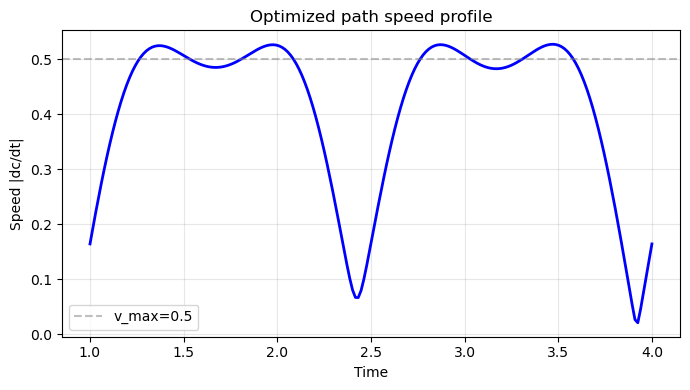

In [16]:
t_dense = np.linspace(t_param[0], t_param[-1], 200)
vx_opt, vy_opt = fourier_velocity(m_opt, t_dense, K, omegas)
speed_opt = np.sqrt(vx_opt**2 + vy_opt**2)

plt.figure(figsize=(7, 4))
plt.plot(t_dense, speed_opt, 'b-', lw=2)
plt.axhline(0.5, color='gray', ls='--', alpha=0.5, label='v_max=0.5')
plt.xlabel('Time'); plt.ylabel('Speed |dc/dt|')
plt.title('Optimized path speed profile')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [17]:
# ═══════════════════════════════════════════════════════════════
# 16.  PARAMETRIC WIND VELOCITY FIELD
# ═══════════════════════════════════════════════════════════════
def computeVelocityField_wind(mesh, direction='east', speed=4.0, Re_val=100.0):
    """
    Wind from a given direction over the unit square.
    
    direction: 'east', 'west', 'north', 'south'
    speed:     peak inlet velocity
    Re_val:    Reynolds number
    """
    Xh = dl.VectorFunctionSpace(mesh, 'Lagrange', 2)
    Wh = dl.FunctionSpace(mesh, 'Lagrange', 1)
    mixed_element = ufl.MixedElement([Xh.ufl_element(), Wh.ufl_element()])
    XW = dl.FunctionSpace(mesh, mixed_element)

    Re = dl.Constant(Re_val)
    bcs = []

    if direction == 'east':
        g = dl.Expression(('s*x[1]*(1.0-x[1])', '0.0'), degree=2, s=speed)
        bcs.append(dl.DirichletBC(XW.sub(0), g, "near(x[0], 0.0)"))
        bcs.append(dl.DirichletBC(XW.sub(0), dl.Constant((0.0, 0.0)),
                   "near(x[1], 0.0) || near(x[1], 1.0)"))

    elif direction == 'west':
        g = dl.Expression(('-s*x[1]*(1.0-x[1])', '0.0'), degree=2, s=speed)
        bcs.append(dl.DirichletBC(XW.sub(0), g, "near(x[0], 1.0)"))
        bcs.append(dl.DirichletBC(XW.sub(0), dl.Constant((0.0, 0.0)),
                   "near(x[1], 0.0) || near(x[1], 1.0)"))

    elif direction == 'north':
        g = dl.Expression(('0.0', 's*x[0]*(1.0-x[0])'), degree=2, s=speed)
        bcs.append(dl.DirichletBC(XW.sub(0), g, "near(x[1], 0.0)"))
        bcs.append(dl.DirichletBC(XW.sub(0), dl.Constant((0.0, 0.0)),
                   "near(x[0], 0.0) || near(x[0], 1.0)"))

    elif direction == 'south':
        g = dl.Expression(('0.0', '-s*x[0]*(1.0-x[0])'), degree=2, s=speed)
        bcs.append(dl.DirichletBC(XW.sub(0), g, "near(x[1], 1.0)"))
        bcs.append(dl.DirichletBC(XW.sub(0), dl.Constant((0.0, 0.0)),
                   "near(x[0], 0.0) || near(x[0], 1.0)"))

    bcs.append(dl.DirichletBC(XW.sub(1), dl.Constant(0), q_boundary, 'pointwise'))

    vq = dl.Function(XW)
    (v, q)           = ufl.split(vq)
    (v_test, q_test) = dl.TestFunctions(XW)

    def strain(v):
        return ufl.sym(ufl.grad(v))

    F = ((2./Re)*ufl.inner(strain(v), strain(v_test))
         + ufl.inner(ufl.nabla_grad(v)*v, v_test)
         - q*ufl.div(v_test)
         + ufl.div(v)*q_test) * ufl.dx

    dl.solve(F == 0, vq, bcs,
             solver_parameters={"newton_solver":
                                 {"relative_tolerance": 1e-4,
                                  "maximum_iterations": 100}})

    vh = dl.project(v, Xh)
    return vh

In [18]:
# ═══════════════════════════════════════════════════════════════
# 17.  RUN OED FOR MULTIPLE WIND SCENARIOS
# ═══════════════════════════════════════════════════════════════

wind_cases = {
    'East wind (baseline)':   ('east',  4.0, 100.0),
    'West wind (reversed)':   ('west',  4.0, 100.0),
    'North wind (upward)':    ('north', 4.0, 100.0),
    'South wind (downward)':  ('south', 4.0, 100.0),
    'Calm east wind':         ('east',  1.5, 100.0),
    'Strong east wind':       ('east',  8.0, 100.0),
}

# Bounds (same for all cases)
lb = np.zeros(4*K + 2)
ub = np.zeros(4*K + 2)
lb[0] = 0.1;  ub[0] = 0.9
lb[1] = 0.1;  ub[1] = 0.9
for kk in range(K):
    for j in range(4):
        lb[2 + 4*kk + j] = -0.3
        ub[2 + 4*kk + j] =  0.3
bounds_all = list(zip(lb, ub))

case_results = {}

for name, (direction, speed, Re_val) in wind_cases.items():
    print(f"\n{'='*60}")
    print(f"  {name}  (dir={direction}, speed={speed}, Re={Re_val})")
    print(f"{'='*60}")
    
    # Compute wind and swap into global
    wind_velocity = computeVelocityField_wind(mesh, direction, speed, Re_val)
    
    # Force full rebuild
    _template_problem = None
    _cached_bbt = None
    eigsolver.reset()
    opt_history = {'eig': [], 'bdy': [], 'spd': [], 'J': [], 'time': []}
    
    # EIG at initial path
    prob_init, _, _ = build_problem(m_fourier_init)
    _, _, eig_init = compute_eigendecomposition(prob_init, prior, r_modes)
    print(f"  Initial EIG = {eig_init:.2f}")
    
    # Optimize
    result = minimize(EIG_objective_and_grad, m_fourier_init,
                      jac=True, method='L-BFGS-B', bounds=bounds_all,
                      options={'maxiter': 80, 'disp': False,
                               'ftol': 1e-10, 'maxls': 40})
    
    m_opt_case = result.x
    
    # Final EIG
    _template_problem = None
    prob_opt, _, _ = build_problem(m_opt_case)
    _, _, eig_opt = compute_eigendecomposition(prob_opt, prior, r_modes)
    
    print(f"  Optimized EIG = {eig_opt:.2f}  ({result.message})")
    
    case_results[name] = {
        'direction': direction,
        'speed': speed,
        'Re': Re_val,
        'wind': wind_velocity.copy(deepcopy=True),
        'm_opt': m_opt_case.copy(),
        'eig_init': eig_init,
        'eig_opt': eig_opt,
        'converged': result.success,
    }

print("\n\nAll cases complete.")


  East wind (baseline)  (dir=east, speed=4.0, Re=100.0)
  Initial EIG = 12.22


/tmp/ipykernel_4066315/938039766.py:47: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(EIG_objective_and_grad, m_fourier_init,


  EIG=12.2231  bdy=0.0000  spd=0.0473  obs=1.0153  [3.4s]
  EIG=21.0256  bdy=8.8576  spd=471649.9021  obs=0.0000  [3.5s]
  EIG=15.9563  bdy=0.8883  spd=233.2031  obs=0.0000  [3.4s]
  EIG=12.9737  bdy=0.0000  spd=0.0288  obs=0.0000  [3.3s]
  EIG=13.4355  bdy=0.0000  spd=0.4509  obs=0.0000  [3.3s]
  EIG=13.1994  bdy=0.0000  spd=0.1507  obs=0.0000  [3.3s]
  EIG=13.4410  bdy=0.0000  spd=0.1808  obs=0.0000  [3.4s]
  EIG=14.5062  bdy=0.0000  spd=0.7829  obs=0.0000  [3.4s]
  EIG=15.8279  bdy=0.0000  spd=0.6424  obs=0.0383  [3.4s]
  EIG=18.3673  bdy=1.3362  spd=45.2269  obs=0.0805  [3.5s]
  EIG=16.1247  bdy=0.0000  spd=0.5115  obs=0.0441  [3.3s]
  EIG=15.2975  bdy=0.0000  spd=0.0000  obs=0.0000  [3.4s]
  EIG=15.8549  bdy=0.0000  spd=0.0096  obs=0.0055  [3.3s]
  EIG=16.2515  bdy=0.0000  spd=0.1255  obs=0.0019  [3.4s]
  EIG=17.3182  bdy=0.1441  spd=0.7758  obs=0.0000  [3.5s]
  EIG=17.2329  bdy=0.0651  spd=0.2632  obs=0.0000  [3.4s]
  EIG=17.6716  bdy=0.2844  spd=0.1426  obs=0.0000  [3.5s]
  EIG=

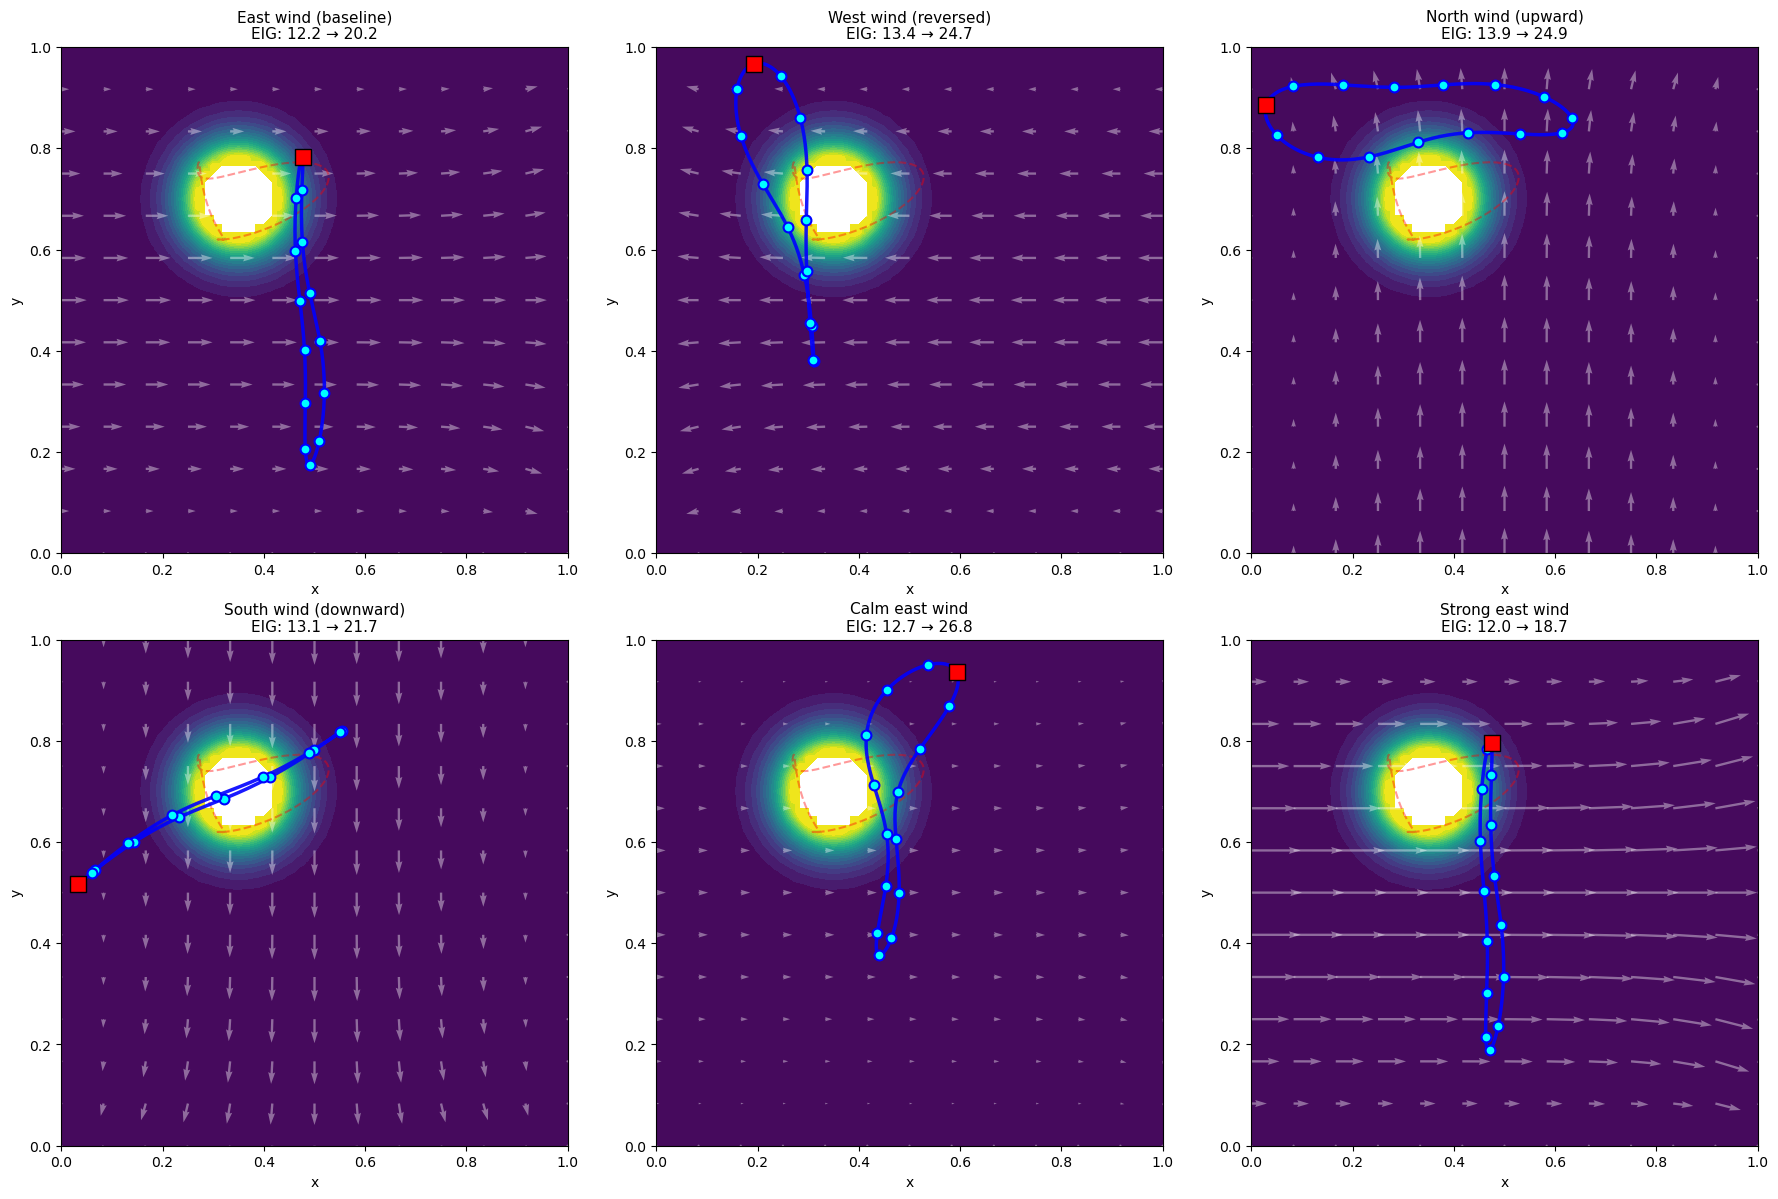

In [19]:
# ═══════════════════════════════════════════════════════════════
# 18.  PLOT: OPTIMAL PATHS FOR ALL WIND SCENARIOS
# ═══════════════════════════════════════════════════════════════

n_cases = len(case_results)
n_cols = 3
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))
axes_flat = axes.flatten()

t_dense = np.linspace(t_param[0], t_param[-1], 200)

for idx, (name, r) in enumerate(case_results.items()):
    ax = axes_flat[idx]
    
    # Background: true IC
    coords = Vh.tabulate_dof_coordinates()
    ic_arr = true_initial_condition.get_local()
    ax.tricontourf(coords[:, 0], coords[:, 1], ic_arr, levels=20, cmap='viridis')
    
    # Velocity quiver
    mc_q = dl.UnitSquareMesh(12, 12)
    vc_q = dl.interpolate(r['wind'], dl.VectorFunctionSpace(mc_q, "CG", 1))
    coords_q = mc_q.coordinates()
    vals_q = vc_q.compute_vertex_values(mc_q)
    n_q = len(coords_q)
    ax.quiver(coords_q[:, 0], coords_q[:, 1],
              vals_q[:n_q], vals_q[n_q:],
              color='white', alpha=0.4, scale=20)
    
    # Initial path (red dashed)
    loop_init = generate_targets(m_fourier_init, t_dense, K, omegas)
    ax.plot(loop_init[:, 0], loop_init[:, 1], 'r--', lw=1.5, alpha=0.4)
    
    # Optimized path (blue solid)
    loop_opt = generate_targets(r['m_opt'], t_dense, K, omegas)
    ax.plot(loop_opt[:, 0], loop_opt[:, 1], 'b-', lw=2.5, alpha=0.9)
    
    # Sensor positions
    tgts_opt = generate_targets(r['m_opt'], t_param, K, omegas)
    ax.scatter(tgts_opt[:, 0], tgts_opt[:, 1], c='cyan', s=50,
               edgecolors='blue', linewidths=1.5, zorder=5)
    
    # Start and end markers
    ax.scatter(tgts_opt[0, 0], tgts_opt[0, 1], c='lime', s=120,
               marker='*', edgecolors='black', linewidths=1, zorder=6)
    ax.scatter(tgts_opt[-1, 0], tgts_opt[-1, 1], c='red', s=120,
               marker='s', edgecolors='black', linewidths=1, zorder=6)
    
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal', 'box')
    ax.set_title(f"{name}\nEIG: {r['eig_init']:.1f} → {r['eig_opt']:.1f}", fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()

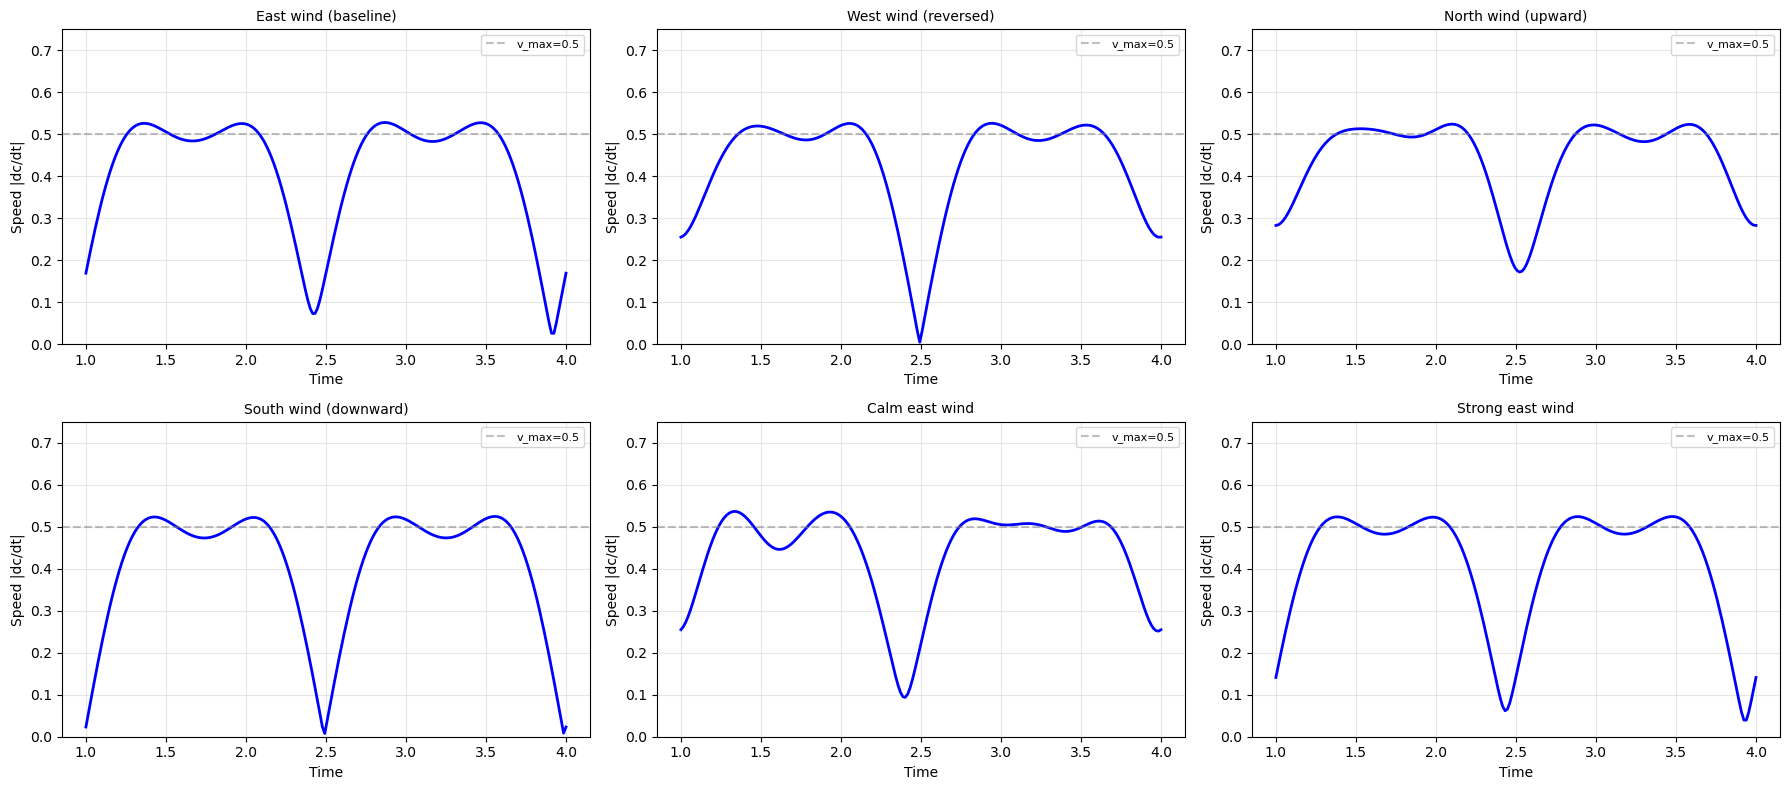

In [20]:
# ═══════════════════════════════════════════════════════════════
# 19.  PLOT: SPEED PROFILES FOR ALL WIND SCENARIOS
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes_flat = axes.flatten()

t_dense = np.linspace(t_param[0], t_param[-1], 200)

for idx, (name, r) in enumerate(case_results.items()):
    ax = axes_flat[idx]
    
    vx_opt, vy_opt = fourier_velocity(r['m_opt'], t_dense, K, omegas)
    speed_opt = np.sqrt(vx_opt**2 + vy_opt**2)
    
    ax.plot(t_dense, speed_opt, 'b-', lw=2)
    ax.axhline(v_max, color='gray', ls='--', alpha=0.5, label=f'v_max={v_max}')
    ax.set_xlabel('Time'); ax.set_ylabel('Speed |dc/dt|')
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, v_max * 1.5)

plt.tight_layout()
plt.show()

In [21]:
# ═══════════════════════════════════════════════════════════════
# 20.  SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════

print(f"\n{'Case':>30s}  {'Dir':>6s}  {'Speed':>6s}  {'Re':>5s}  "
      f"{'EIG init':>9s}  {'EIG opt':>9s}  {'Gain':>7s}  {'Conv':>5s}")
print("-" * 90)
for name, r in case_results.items():
    gain = r['eig_opt'] - r['eig_init']
    conv = 'Yes' if r['converged'] else 'No'
    print(f"{name:>30s}  {r['direction']:>6s}  {r['speed']:6.1f}  {r['Re']:5.0f}  "
          f"{r['eig_init']:9.2f}  {r['eig_opt']:9.2f}  {gain:+7.2f}  {conv:>5s}")

# Optimal Fourier coefficients comparison
print(f"\n{'Case':>30s}  {'x̄':>6s}  {'ȳ':>6s}  {'θ₁':>6s}  {'φ₁':>6s}  {'ψ₁':>6s}  {'η₁':>6s}")
print("-" * 72)
for name, r in case_results.items():
    m = r['m_opt']
    print(f"{name:>30s}  {m[0]:6.3f}  {m[1]:6.3f}  {m[2]:6.3f}  "
          f"{m[3]:6.3f}  {m[4]:6.3f}  {m[5]:6.3f}")


                          Case     Dir   Speed     Re   EIG init    EIG opt     Gain   Conv
------------------------------------------------------------------------------------------
          East wind (baseline)    east     4.0    100      12.22      20.23    +8.01     No
          West wind (reversed)    west     4.0    100      13.36      24.65   +11.29    Yes
           North wind (upward)   north     4.0    100      13.88      24.91   +11.03     No
         South wind (downward)   south     4.0    100      13.11      21.74    +8.63     No
                Calm east wind    east     1.5    100      12.74      26.77   +14.02     No
              Strong east wind    east     8.0    100      11.99      18.66    +6.66     No

                          Case      x̄       ȳ      θ₁      φ₁      ψ₁      η₁
------------------------------------------------------------------------
          East wind (baseline)   0.484   0.483  -0.009  -0.019  -0.099   0.270
          West wind (reversed)  

NameError: name 'curved_cases' is not defined

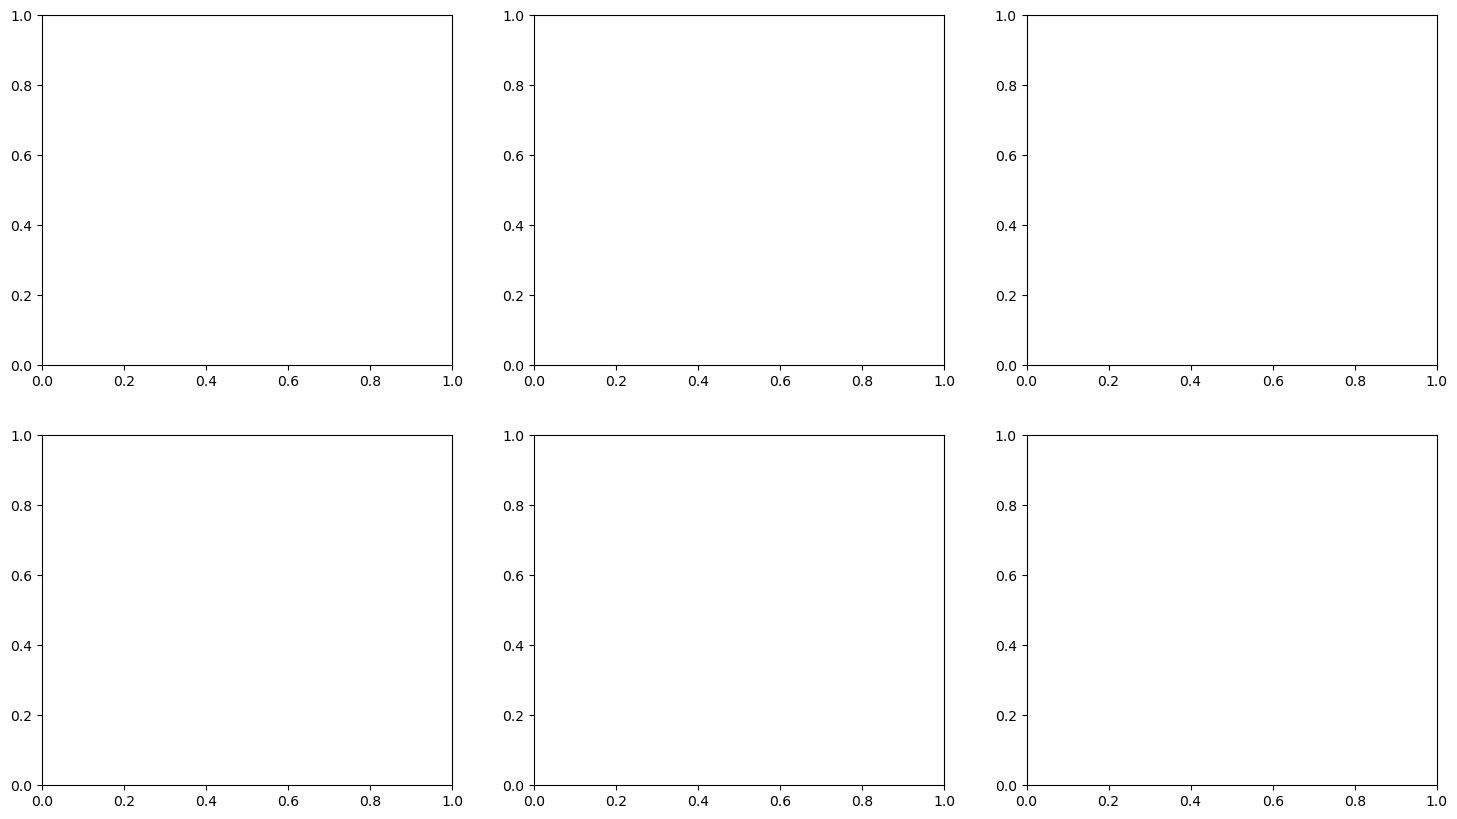

In [22]:
# ═══════════════════════════════════════════════════════════════
# CURVED WIND FIELDS VIA STREAM FUNCTION
# ═══════════════════════════════════════════════════════════════
def construct_curved_wind(mesh, pattern='vortex', strength=1.0,
                          center=(0.5, 0.5), mean_vx=0.5):
    """
    Construct curved, divergence-free wind field with v_y=0 at y=0,1.
    
    Uses a stream function ψ(x,y) with ψ=const on y=0 and y=1.
    v_x = dψ/dy + mean_vx,   v_y = -dψ/dx
    
    mean_vx : horizontal mean wind (no vertical mean allowed — 
              would violate v_y=0 at walls)
    
    Patterns:
        'vortex'      : rotation embedded in mean flow
        'dipole'       : two counter-rotating cells
        'shear'        : wind turning across domain
        'channel'      : flow deflected around an obstacle
        'converging'   : winds converging toward centerline
    """
    Xh = dl.VectorFunctionSpace(mesh, 'Lagrange', 1)
    xy = mesh.coordinates()
    x = xy[:, 0]
    y = xy[:, 1]
    
    cx, cy = center
    
    # Wall damping: sin(πy) vanishes at y=0 and y=1
    # This ensures ψ = 0 at walls → v_y = -dψ/dx = 0 at walls
    wall = np.sin(np.pi * y)
    dwall_dy = np.pi * np.cos(np.pi * y)
    
    if pattern == 'vortex':
        sigma = 0.3
        r2 = (x - cx)**2 + (y - cy)**2
        psi_raw = -strength * np.exp(-r2 / (2 * sigma**2))
        dpsi_raw_dx = strength * (x - cx) / sigma**2 * np.exp(-r2 / (2 * sigma**2))
        dpsi_raw_dy = strength * (y - cy) / sigma**2 * np.exp(-r2 / (2 * sigma**2))
    
    elif pattern == 'dipole':
        sigma = 0.25
        r2_left  = (x - 0.3)**2 + (y - cy)**2
        r2_right = (x - 0.7)**2 + (y - cy)**2
        psi_raw = -strength * (np.exp(-r2_left / (2*sigma**2)) 
                              - np.exp(-r2_right / (2*sigma**2)))
        dpsi_raw_dx = strength * ((x-0.3)/sigma**2 * np.exp(-r2_left/(2*sigma**2))
                                 -(x-0.7)/sigma**2 * np.exp(-r2_right/(2*sigma**2)))
        dpsi_raw_dy = strength * ((y-cy)/sigma**2 * np.exp(-r2_left/(2*sigma**2))
                                 -(y-cy)/sigma**2 * np.exp(-r2_right/(2*sigma**2)))
    
    elif pattern == 'shear':
        psi_raw = strength * np.cos(np.pi * x)
        dpsi_raw_dx = -strength * np.pi * np.sin(np.pi * x)
        dpsi_raw_dy = np.zeros_like(x)
    
    elif pattern == 'channel':
        sigma = 0.2
        amplitude = 0.5 * strength
        r2 = (x - cx)**2 + (y - cy)**2
        psi_raw = amplitude * np.exp(-r2 / (2*sigma**2))
        dpsi_raw_dx = -amplitude * (x-cx)/sigma**2 * np.exp(-r2/(2*sigma**2))
        dpsi_raw_dy = -amplitude * (y-cy)/sigma**2 * np.exp(-r2/(2*sigma**2))
    
    elif pattern == 'converging':
        psi_raw = strength * x * (y - 0.5)
        dpsi_raw_dx = strength * (y - 0.5)
        dpsi_raw_dy = strength * x
    
    # Apply wall damping: ψ = ψ_raw * sin(πy)
    # dψ/dx = dψ_raw/dx * sin(πy)
    # dψ/dy = dψ_raw/dy * sin(πy) + ψ_raw * π*cos(πy)
    dpsi_dx = dpsi_raw_dx * wall
    dpsi_dy = dpsi_raw_dy * wall + psi_raw * dwall_dy
    
    # Velocity: vx = dψ/dy + mean_vx,  vy = -dψ/dx
    vx = dpsi_dy + mean_vx
    vy = -dpsi_dx
    
    # Build dolfin function
    v_func = dl.Function(Xh)
    vals = v_func.vector().get_local()
    for i in range(len(xy)):
        vals[2*i]     = vx[i]
        vals[2*i + 1] = vy[i]
    v_func.vector().set_local(vals)
    
    # Safety: cap maximum velocity
    max_speed = np.sqrt(vx**2 + vy**2).max()
    safe_max = 2.0
    if max_speed > safe_max:
        print(f"  Rescaling wind: max speed {max_speed:.2f} → {safe_max:.2f}")
        v_func.vector()[:] *= safe_max / max_speed
    
    return v_func

# ── Visualize all curved wind patterns ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

curved_oed_cases = {
    'Vortex (thermal eddy)':    ('vortex',     0.8, (0.5, 0.5), 0.5),
    'Dipole (frontal passage)': ('dipole',     0.6, (0.5, 0.5), 0.3),
    'Shear (turning wind)':     ('shear',      0.15,(0.5, 0.5), 0.5),
    'Channel (deflected flow)': ('channel',    1.0, (0.5, 0.6), 0.5),
    'Converging (conv. zone)':  ('converging', 0.8, (0.5, 0.5), 0.5),
    'Vortex + strong east':     ('vortex',     0.6, (0.4, 0.6), 1.0),
}

for idx, (label, pattern, strength, center, mean) in enumerate(curved_cases):
    ax = axes[idx // 3][idx % 3]
    
    v_test = construct_curved_wind(mesh, pattern, strength, center, mean)
    
    # Plot on coarse grid
    mc_q = dl.UnitSquareMesh(18, 18)
    vc_q = dl.interpolate(v_test, dl.VectorFunctionSpace(mc_q, "CG", 1))
    coords_q = mc_q.coordinates()
    vals_q = vc_q.compute_vertex_values(mc_q)
    n_q = len(coords_q)
    
    speed_field = np.sqrt(vals_q[:n_q]**2 + vals_q[n_q:]**2)
    
    ax.quiver(coords_q[:, 0], coords_q[:, 1],
              vals_q[:n_q], vals_q[n_q:],
              speed_field, cmap='coolwarm', alpha=0.8, scale=12)
    
    # Show IC blob contour
    coords_vh = Vh.tabulate_dof_coordinates()
    ic_arr = true_initial_condition.get_local()
    ax.tricontour(coords_vh[:, 0], coords_vh[:, 1], ic_arr,
                  levels=[0.2], colors='lime', linewidths=2)
    
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal', 'box')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# RUN OED ON CURVED WIND FIELDS
# ═══════════════════════════════════════════════════════════════

curved_oed_cases = {
    'Vortex (thermal eddy)':    ('vortex',     0.8, (0.5, 0.5), (0.5, 0.0)),
    'Dipole (frontal passage)': ('dipole',     0.6, (0.5, 0.5), (0.3, 0.0)),
    'Shear (turning wind)':     ('shear',      0.5, (0.5, 0.5), (0.5, 0.0)),
    'Channel (deflected flow)': ('channel',    1.0, (0.5, 0.6), (0.0, 0.0)),
    'Converging (conv. zone)':  ('converging', 0.8, (0.5, 0.5), (0.5, 0.0)),
    'Vortex + NE mean':         ('vortex',     0.6, (0.4, 0.6), (0.4, 0.3)),
}

# Bounds
lb = np.zeros(4*K + 2)
ub = np.zeros(4*K + 2)
lb[0] = 0.1;  ub[0] = 0.9
lb[1] = 0.1;  ub[1] = 0.9
for kk in range(K):
    for j in range(4):
        lb[2 + 4*kk + j] = -0.3
        ub[2 + 4*kk + j] =  0.3
bounds_all = list(zip(lb, ub))

curved_results = {}

for name, (pattern, strength, center, mean) in curved_oed_cases.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    
    # Build curved wind and swap into global
    wind_velocity = construct_curved_wind(mesh, pattern, strength, center, mean)
    
    # Force full rebuild
    _template_problem = None
    _cached_bbt = None
    eigsolver.reset()
    opt_history = {'eig': [], 'bdy': [], 'spd': [], 'J': [], 'time': []}
    
    # EIG at initial path
    prob_init, _, _ = build_problem(m_fourier_init)
    _, _, eig_init = compute_eigendecomposition(prob_init, prior, r_modes)
    print(f"  Initial EIG = {eig_init:.2f}")
    
    # Optimize
    result = minimize(EIG_objective_and_grad, m_fourier_init,
                      jac=True, method='L-BFGS-B', bounds=bounds_all,
                      options={'maxiter': 80, 'disp': False,
                               'ftol': 1e-10, 'maxls': 40})
    
    m_opt_case = result.x
    
    # Final EIG
    _template_problem = None
    prob_opt, _, _ = build_problem(m_opt_case)
    _, _, eig_opt = compute_eigendecomposition(prob_opt, prior, r_modes)
    
    print(f"  Optimized EIG = {eig_opt:.2f}  ({result.message})")
    
    curved_results[name] = {
        'pattern': pattern,
        'strength': strength,
        'center': center,
        'mean_flow': mean,
        'wind': wind_velocity.copy(deepcopy=True),
        'm_opt': m_opt_case.copy(),
        'eig_init': eig_init,
        'eig_opt': eig_opt,
        'converged': result.success,
    }

print("\n\nAll curved cases complete.")


  Vortex (thermal eddy)
  Rescaling wind: max speed 2.12 → 2.00
  Initial EIG = 55.19
  EIG=55.1871  bdy=0.0000  spd=0.0473  [2.3s]
  EIG=40.3570  bdy=11.3740  spd=347835.7603  [2.3s]
  EIG=63.9172  bdy=0.0000  spd=172.8435  [2.3s]
  EIG=59.9466  bdy=0.0000  spd=0.3811  [2.4s]
  EIG=60.4646  bdy=0.0000  spd=0.0180  [2.2s]
  EIG=63.3978  bdy=0.0000  spd=0.0095  [2.3s]
  EIG=63.1888  bdy=0.0000  spd=0.0280  [2.2s]
  EIG=64.0731  bdy=0.0000  spd=0.0134  [2.2s]
  EIG=64.8044  bdy=0.0000  spd=0.0047  [2.3s]
  EIG=68.1543  bdy=0.0000  spd=0.0103  [2.2s]
  EIG=69.4685  bdy=0.0000  spd=19.3426  [2.2s]
  EIG=69.4207  bdy=0.0000  spd=0.1562  [2.1s]
  EIG=70.6179  bdy=0.0000  spd=0.2252  [2.2s]
  EIG=70.7258  bdy=0.0000  spd=0.7765  [2.3s]
  EIG=71.2037  bdy=0.0000  spd=0.3493  [2.3s]
  EIG=71.3469  bdy=0.0000  spd=7.8305  [2.2s]
  EIG=70.9063  bdy=0.0000  spd=0.6135  [2.2s]
  EIG=71.3071  bdy=0.0000  spd=0.3866  [2.2s]
  EIG=71.4535  bdy=0.0000  spd=0.2837  [2.1s]
  EIG=71.3659  bdy=0.0000  spd

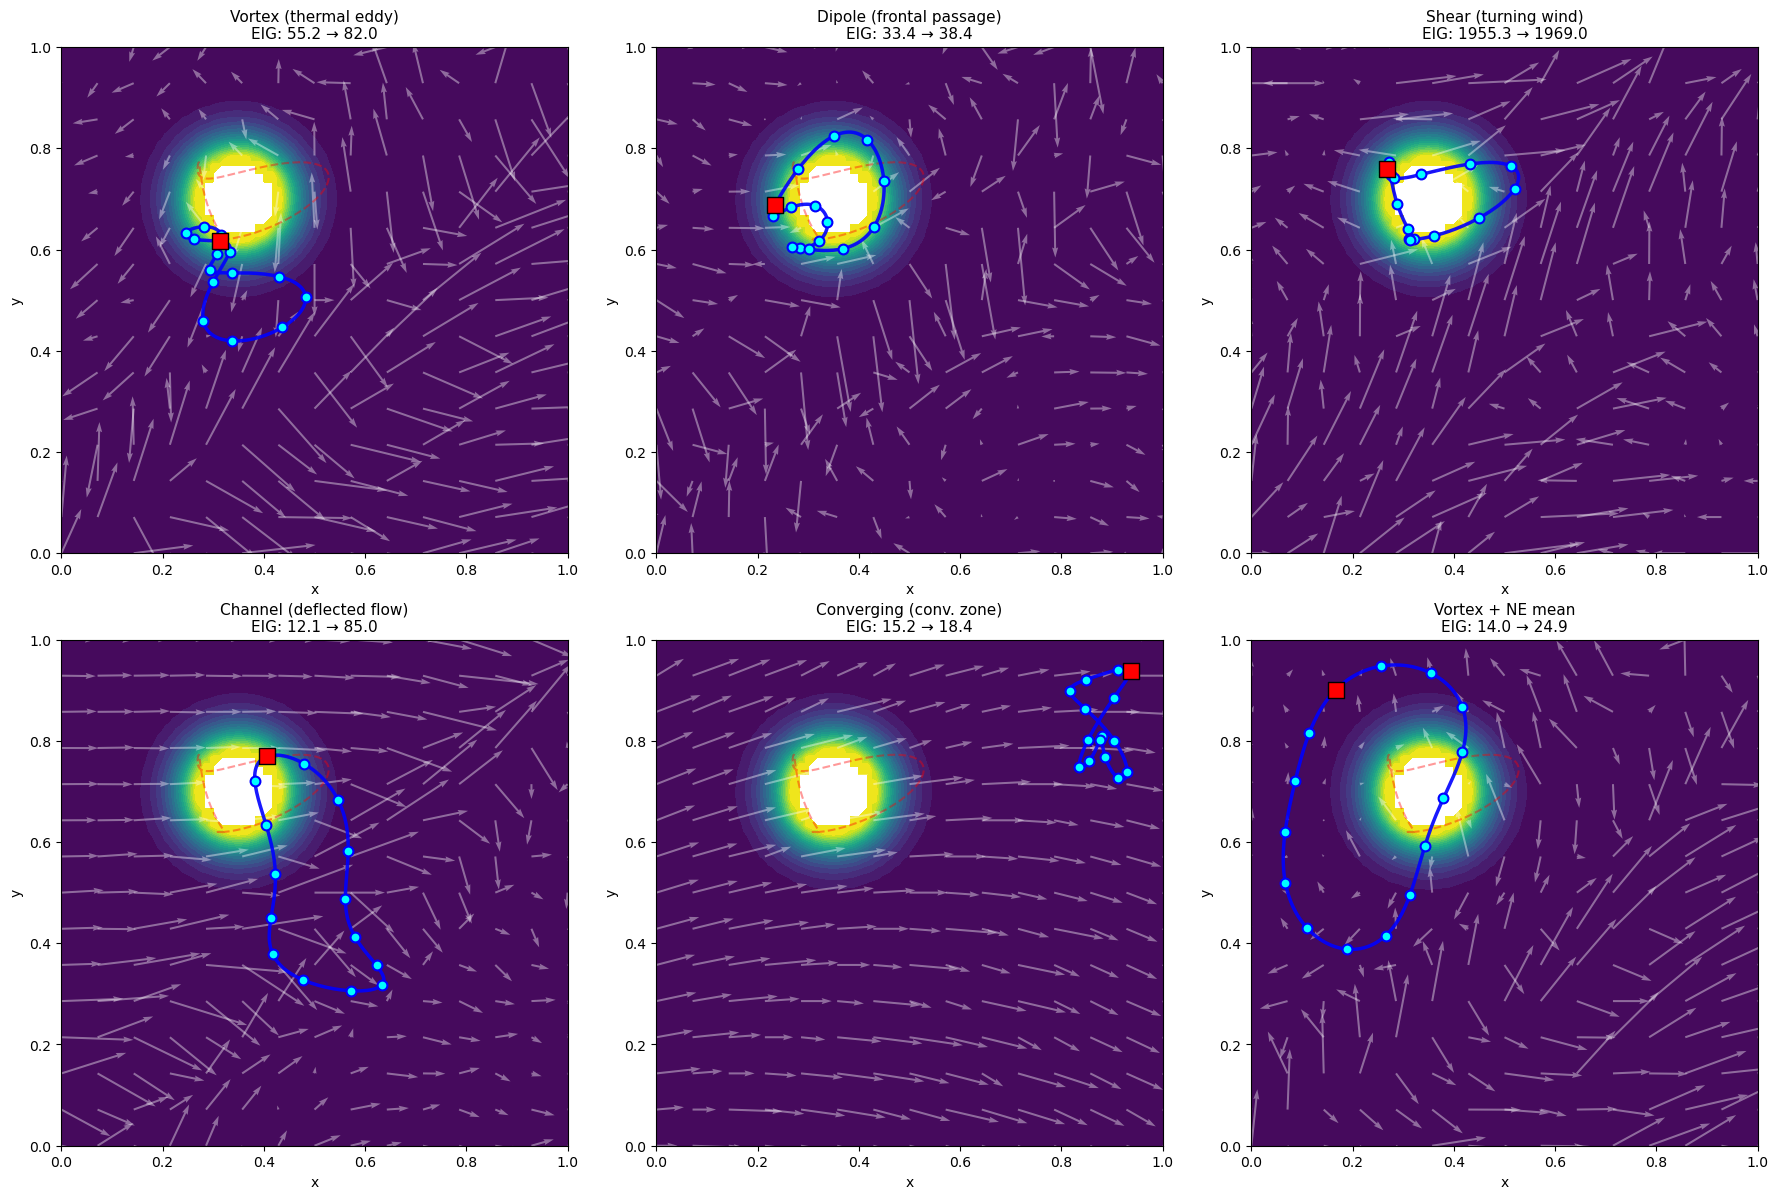

In [ ]:
# ═══════════════════════════════════════════════════════════════
# PLOT: OPTIMAL PATHS ON CURVED WIND FIELDS
# ═══════════════════════════════════════════════════════════════

n_cases = len(curved_results)
n_cols = 3
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))
axes_flat = axes.flatten()

t_dense = np.linspace(t_param[0], t_param[-1], 200)

for idx, (name, r) in enumerate(curved_results.items()):
    ax = axes_flat[idx]
    
    # Background: true IC
    coords = Vh.tabulate_dof_coordinates()
    ic_arr = true_initial_condition.get_local()
    ax.tricontourf(coords[:, 0], coords[:, 1], ic_arr, levels=20, cmap='viridis')
    
    # Velocity quiver
    mc_q = dl.UnitSquareMesh(14, 14)
    vc_q = dl.interpolate(r['wind'], dl.VectorFunctionSpace(mc_q, "CG", 1))
    coords_q = mc_q.coordinates()
    vals_q = vc_q.compute_vertex_values(mc_q)
    n_q = len(coords_q)
    ax.quiver(coords_q[:, 0], coords_q[:, 1],
              vals_q[:n_q], vals_q[n_q:],
              color='white', alpha=0.4, scale=12)
    
    # Initial path (red dashed)
    loop_init = generate_targets(m_fourier_init, t_dense, K, omegas)
    ax.plot(loop_init[:, 0], loop_init[:, 1], 'r--', lw=1.5, alpha=0.4)
    
    # Optimized path (blue solid)
    loop_opt = generate_targets(r['m_opt'], t_dense, K, omegas)
    ax.plot(loop_opt[:, 0], loop_opt[:, 1], 'b-', lw=2.5, alpha=0.9)
    
    # Sensor positions
    tgts_opt = generate_targets(r['m_opt'], t_param, K, omegas)
    ax.scatter(tgts_opt[:, 0], tgts_opt[:, 1], c='cyan', s=50,
               edgecolors='blue', linewidths=1.5, zorder=5)
    
    # Start and end markers
    ax.scatter(tgts_opt[0, 0], tgts_opt[0, 1], c='lime', s=120,
               marker='*', edgecolors='black', linewidths=1, zorder=6)
    ax.scatter(tgts_opt[-1, 0], tgts_opt[-1, 1], c='red', s=120,
               marker='s', edgecolors='black', linewidths=1, zorder=6)
    
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal', 'box')
    ax.set_title(f"{name}\nEIG: {r['eig_init']:.1f} → {r['eig_opt']:.1f}", fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()

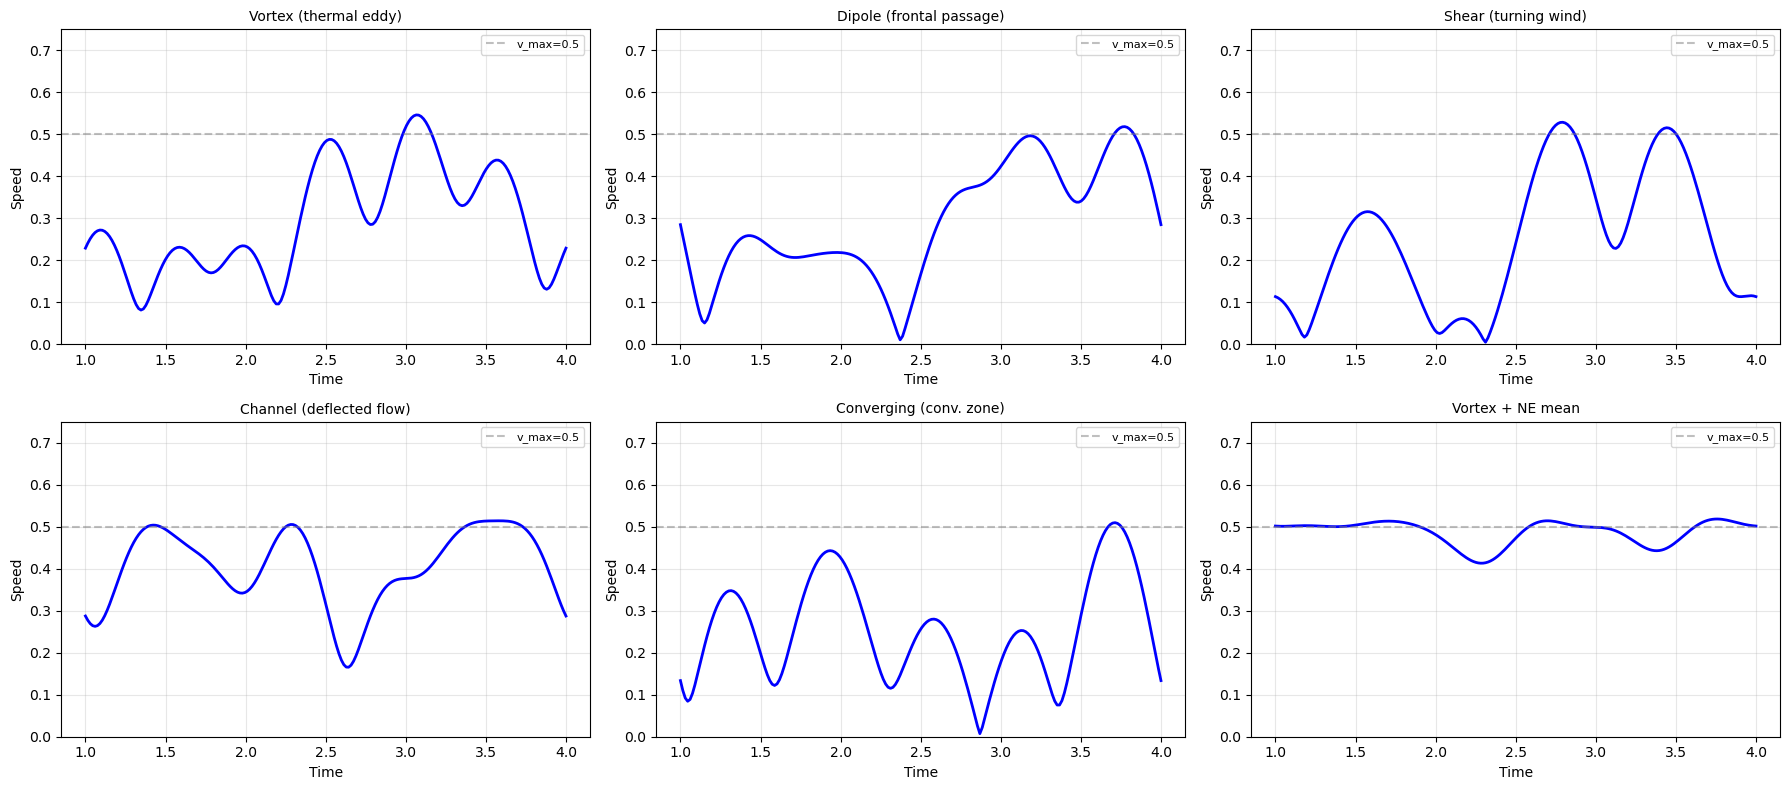

In [ ]:
# ═══════════════════════════════════════════════════════════════
# SPEED PROFILES FOR CURVED WIND CASES
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes_flat = axes.flatten()

for idx, (name, r) in enumerate(curved_results.items()):
    ax = axes_flat[idx]
    vx_opt, vy_opt = fourier_velocity(r['m_opt'], t_dense, K, omegas)
    speed_opt = np.sqrt(vx_opt**2 + vy_opt**2)
    ax.plot(t_dense, speed_opt, 'b-', lw=2)
    ax.axhline(v_max, color='gray', ls='--', alpha=0.5, label=f'v_max={v_max}')
    ax.set_xlabel('Time'); ax.set_ylabel('Speed')
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, v_max * 1.5)

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# SUMMARY TABLE FOR CURVED WIND CASES
# ═══════════════════════════════════════════════════════════════

print(f"\n{'Case':>30s}  {'Pattern':>12s}  {'Mean flow':>12s}  "
      f"{'EIG init':>9s}  {'EIG opt':>9s}  {'Gain':>7s}  {'Conv':>5s}")
print("-" * 95)
for name, r in curved_results.items():
    gain = r['eig_opt'] - r['eig_init']
    conv = 'Yes' if r['converged'] else 'No'
    mf = f"({r['mean_flow'][0]:.1f},{r['mean_flow'][1]:.1f})"
    print(f"{name:>30s}  {r['pattern']:>12s}  {mf:>12s}  "
          f"{r['eig_init']:9.2f}  {r['eig_opt']:9.2f}  {gain:+7.2f}  {conv:>5s}")

print(f"\n{'Case':>30s}  {'x̄':>6s}  {'ȳ':>6s}  {'θ₁':>6s}  {'φ₁':>6s}  {'ψ₁':>6s}  {'η₁':>6s}")
print("-" * 72)
for name, r in curved_results.items():
    m = r['m_opt']
    print(f"{name:>30s}  {m[0]:6.3f}  {m[1]:6.3f}  {m[2]:6.3f}  "
          f"{m[3]:6.3f}  {m[4]:6.3f}  {m[5]:6.3f}")


                          Case       Pattern     Mean flow   EIG init    EIG opt     Gain   Conv
-----------------------------------------------------------------------------------------------
         Vortex (thermal eddy)        vortex     (0.5,0.0)      55.19      81.98   +26.79    Yes
      Dipole (frontal passage)        dipole     (0.3,0.0)      33.42      38.39    +4.97    Yes
          Shear (turning wind)         shear     (0.5,0.0)    1955.26    1969.02   +13.76    Yes
      Channel (deflected flow)       channel     (0.0,0.0)      12.06      85.04   +72.99     No
       Converging (conv. zone)    converging     (0.5,0.0)      15.17      18.40    +3.22     No
              Vortex + NE mean        vortex     (0.4,0.3)      13.98      24.91   +10.93    Yes

                          Case      x̄       ȳ      θ₁      φ₁      ψ₁      η₁
------------------------------------------------------------------------
         Vortex (thermal eddy)   0.330   0.557   0.066  -0.027  -0.091 